# Behavioral Cloning + RL Fine-Tuning on LunarLander-v3

## CSC_52081_EP — Reinforcement Learning and Autonomous Agents
### Institut Polytechnique de Paris — 2026

---

**Abstract.** We study the combination of Behavioral Cloning (BC) and Reinforcement Learning (RL) fine-tuning for the `LunarLander-v3` discrete-control environment. An expert policy trained via PPO provides demonstration trajectories that are used to pretrain a policy network through supervised learning (BC). We then fine-tune this BC-initialized policy using three RL algorithms: REINFORCE, A2C, and PPO, and systematically ablate over demonstration dataset size, expert quality, observation noise augmentation, action noise in data collection, and KL-divergence regularization. Our central finding is that BC initialization dramatically accelerates RL convergence, while RL fine-tuning corrects the covariate shift inherent to pure imitation learning.

## Table of Contents

1. [Introduction and Motivation](#1-introduction-and-motivation)
2. [Pipeline Overview](#2-pipeline-overview)
3. [Experiment 1: Main Comparison — RL Scratch vs BC Only vs BC+REINFORCE](#3-experiment-1-main-comparison)
4. [Experiment 2: Demonstration Dataset Size Ablation](#4-experiment-2-demo-size-ablation)
5. [Experiment 3: Expert Quality Ablation](#5-experiment-3-expert-quality-ablation)
6. [Experiment 4: BC + PPO Fine-Tuning and Entropy Annealing](#6-experiment-4-bc--ppo-fine-tuning)
7. [Experiment 5: Observation Noise Augmentation](#7-experiment-5-observation-noise-augmentation)
8. [Experiment 6: RL Method Comparison — REINFORCE vs A2C vs PPO](#8-experiment-6-rl-method-comparison)
9. [Experiment 7: Action Noise and KL Divergence Regularization](#9-experiment-7-action-noise-and-kl-divergence)
10. [Summary and Conclusions](#10-summary-and-conclusions)
11. [References](#11-references)
12. [Appendix: Hyperparameters](#12-appendix-hyperparameters)

In [44]:
import os
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
from pathlib import Path
from IPython.display import display, Image, Markdown, SVG

# Project imports
from src.policy import PolicyNetwork, ActorCriticNetwork
from src.expert import DemonstrationDataset, ExpertConfig
from src.bc import BehavioralCloning, BCConfig
from src.rl import REINFORCETrainer, REINFORCEConfig, A2CTrainer, A2CConfig
from src.evaluate import evaluate_policy, measure_covariate_shift

sns.set_theme(style="whitegrid", palette="colorblind")
%matplotlib inline

# Paths
RESULTS_DIR = "results"
FIGURES_DIR = "figures"
DATA_DIR = "data"
CHECKPOINT_DIR = "checkpoints"

# Environment constants
ENV_ID = "LunarLander-v3"
OBS_DIM = 8
ACT_DIM = 4
THRESHOLD = 200.0

In [45]:
def load_results(name):
    """Load a saved experiment results dict from .npy file."""
    path = os.path.join(RESULTS_DIR, name)
    return np.load(path, allow_pickle=True).item()


def smooth(arr, window=5):
    """Simple moving-average smoother for learning curves."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")

---
<a id="1-introduction-and-motivation"></a>
## 1. Introduction and Motivation

### The Problem: Covariate Shift in Behavioral Cloning

**Behavioral Cloning (BC)** is the simplest form of imitation learning: given a dataset of expert demonstrations $\{(s_i, a_i)\}$, we train a policy $\pi_\theta$ to minimize a supervised loss (e.g., cross-entropy for discrete actions) on expert state-action pairs:

$$\min_\theta \; \mathbb{E}_{s \sim d_{\text{expert}}} \left[ \ell\bigl(\pi_\theta(s), \, a_{\text{expert}}(s)\bigr) \right]$$

The fundamental limitation is **covariate shift** (Ross & Bagnell, 2010): BC minimizes loss under the *expert's* state distribution $d_{\text{expert}}$, but at deployment the agent follows its *own* distribution $d_{\pi_\theta}$. Small errors compound over time because the agent visits states that were never seen during training, leading to an error bound that grows as $O(T^2 \epsilon)$ where $T$ is the horizon and $\epsilon$ is the per-step error rate.

### The Solution: RL Fine-Tuning

RL fine-tuning addresses covariate shift by optimizing the policy under its *own* state distribution:

$$\max_\theta \; \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T} \gamma^t r(s_t, a_t) \right]$$

By initializing from BC weights, RL fine-tuning starts from a reasonable policy (rather than random), which provides:
- **Faster convergence**: the policy already knows roughly what to do.
- **Better sample efficiency**: fewer environment interactions needed.
- **Higher final performance**: RL corrects BC's distributional mismatch.

### Research Questions

This project systematically investigates seven questions:

1. Does BC+REINFORCE outperform BC-only and RL-from-scratch?
2. How does demonstration dataset size affect BC and BC+RL?
3. How does expert quality affect the BC+RL pipeline?
4. Can PPO fine-tuning (with/without entropy annealing) improve over REINFORCE?
5. Does observation noise augmentation during BC reduce covariate shift?
6. Which RL method (REINFORCE vs A2C vs PPO) works best for fine-tuning?
7. Do action noise in data collection and KL regularization improve training stability?

### Environment: LunarLander-v3

We use the Gymnasium `LunarLander-v3` environment throughout all experiments. It provides:

| Property | Value |
|----------|-------|
| Observation space | 8-dimensional continuous (x, y, velocity_x, velocity_y, angle, angular_velocity, left_leg_contact, right_leg_contact) |
| Action space | Discrete(4): do nothing, fire left engine, fire main engine, fire right engine |
| Reward | +100–140 for landing on pad, -100 for crashing, small per-step fuel cost |
| Success threshold | Mean return $\geq$ 200 |

This environment strikes a good balance: non-trivial dynamics requiring real learning, but fast enough for multi-seed experiments on a single machine.

In [46]:
env = gym.make(ENV_ID)
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Observation shape:  {env.observation_space.shape}")
print(f"Number of actions:  {env.action_space.n}")
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space:      Discrete(4)
Observation shape:  (8,)
Number of actions:  4


---
<a id="2-pipeline-overview"></a>
## 2. Pipeline Overview

The project follows a four-stage pipeline:

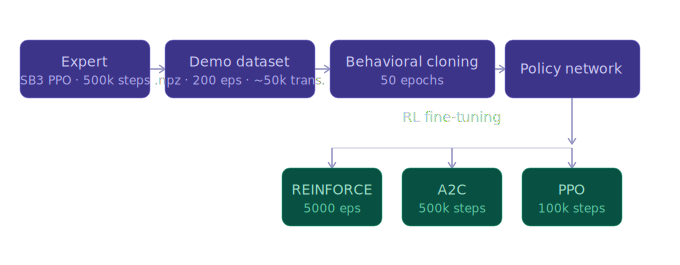

In [86]:
display(SVG(filename='figures/rl_pipeline_overview.svg'))

Each stage is implemented as a separate module in `src/`, enabling flexible composition across experiments.

### 2.1 Policy Architectures

Two network architectures are shared across all methods:

- **`PolicyNetwork`** (actor-only): MLP with hidden layers `[256, 256]` and Tanh activations, mapping observations to action logits. Used by BC and REINFORCE.
- **`ActorCriticNetwork`** (shared trunk): Same hidden dimensions but with a shared trunk feeding separate actor and critic heads. Used by A2C.

The choice of `[256, 256]` hidden dimensions is important: when transferring BC weights to SB3's PPO, the PPO network must use `net_arch=[256, 256]` to match (the SB3 default of `[64, 64]` would cause a dimension mismatch).

In [47]:
# Display the two network architectures
policy = PolicyNetwork(OBS_DIM, ACT_DIM)
print("PolicyNetwork (actor-only, used by BC and REINFORCE):")
print(policy)
print(f"\nTotal parameters: {sum(p.numel() for p in policy.parameters()):,}")

print("\n" + "="*60 + "\n")

ac = ActorCriticNetwork(OBS_DIM, ACT_DIM)
print("ActorCriticNetwork (shared trunk, used by A2C):")
print(ac)
print(f"\nTotal parameters: {sum(p.numel() for p in ac.parameters()):,}")

PolicyNetwork (actor-only, used by BC and REINFORCE):
PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

Total parameters: 69,124


ActorCriticNetwork (shared trunk, used by A2C):
ActorCriticNetwork(
  (trunk): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): Tanh()
  )
  (actor_head): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=4, bias=True)
  )
  (critic_head): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
)

Total parameters: 135,173


### 2.2 Expert Training

The expert policy is a PPO agent trained via Stable-Baselines3 for 500k timesteps with 4 parallel environments. Intermediate checkpoints are saved every 50k steps (used later for the expert quality ablation). The best model is selected by an `EvalCallback` that evaluates every 10k steps over 20 episodes.

> **Note:** Expert training was performed offline. The checkpoints are stored in `checkpoints/expert/`.

In [48]:
# Show expert training configuration
cfg = ExpertConfig()
print(f"Environment:          {cfg.env_id}")
print(f"Total timesteps:      {cfg.total_timesteps:,}")
print(f"Parallel envs:        {cfg.n_envs}")
print(f"Checkpoint frequency: every {cfg.checkpoint_freq:,} steps")

# List saved expert checkpoints
expert_checkpoints = sorted(Path(CHECKPOINT_DIR, "expert").glob("*.zip"))
print(f"\nSaved checkpoints ({len(expert_checkpoints)} files):")
for p in expert_checkpoints:
    print(f"  {p.name}")

Environment:          LunarLander-v3
Total timesteps:      500,000
Parallel envs:        4
Checkpoint frequency: every 50,000 steps

Saved checkpoints (11 files):
  expert_final.zip
  expert_ppo_100000_steps.zip
  expert_ppo_150000_steps.zip
  expert_ppo_200000_steps.zip
  expert_ppo_250000_steps.zip
  expert_ppo_300000_steps.zip
  expert_ppo_350000_steps.zip
  expert_ppo_400000_steps.zip
  expert_ppo_450000_steps.zip
  expert_ppo_500000_steps.zip
  expert_ppo_50000_steps.zip


### 2.3 Demonstration Collection

The `collect_demonstrations()` function rolls out the expert policy deterministically for a specified number of episodes, recording `(observation, action)` pairs and episode returns. The dataset is stored as a `.npz` file.

An important extension is the `action_noise_eps` parameter: with probability $\epsilon$, the *executed* action is replaced with a random one (epsilon-greedy noise), while the *recorded* action remains the expert's optimal choice. This forces the expert into slightly off-trajectory states and demonstrates recovery behavior — a direct attack on covariate shift at the data-collection level (explored in Experiment 7).

In [49]:
# Load and inspect the main demonstration dataset
demo = DemonstrationDataset.load(os.path.join(DATA_DIR, "demonstrations_200ep.npz"))

print(f"Dataset summary:")
print(f"  Total transitions:   {len(demo):,}")
print(f"  Observation shape:   {demo.observations.shape}")
print(f"  Action shape:        {demo.actions.shape}")
print(f"  Episodes:            {len(demo.episode_returns)}")
print(f"  Mean episode return: {np.mean(demo.episode_returns):.1f} +/- {np.std(demo.episode_returns):.1f}")
print(f"  Min / Max return:    {np.min(demo.episode_returns):.1f} / {np.max(demo.episode_returns):.1f}")

print(f"\nAction distribution:")
action_names = ["Do nothing", "Fire left", "Fire main", "Fire right"]
unique, counts = np.unique(demo.actions, return_counts=True)
for a, c in zip(unique, counts):
    print(f"  {a} ({action_names[a]}): {c:,} ({100*c/len(demo.actions):.1f}%)")

Dataset summary:
  Total transitions:   55,176
  Observation shape:   (55176, 8)
  Action shape:        (55176,)
  Episodes:            200
  Mean episode return: 268.5 +/- 21.2
  Min / Max return:    150.9 / 312.2

Action distribution:
  0 (Do nothing): 11,173 (20.2%)
  1 (Fire left): 9,311 (16.9%)
  2 (Fire main): 25,061 (45.4%)
  3 (Fire right): 9,631 (17.5%)


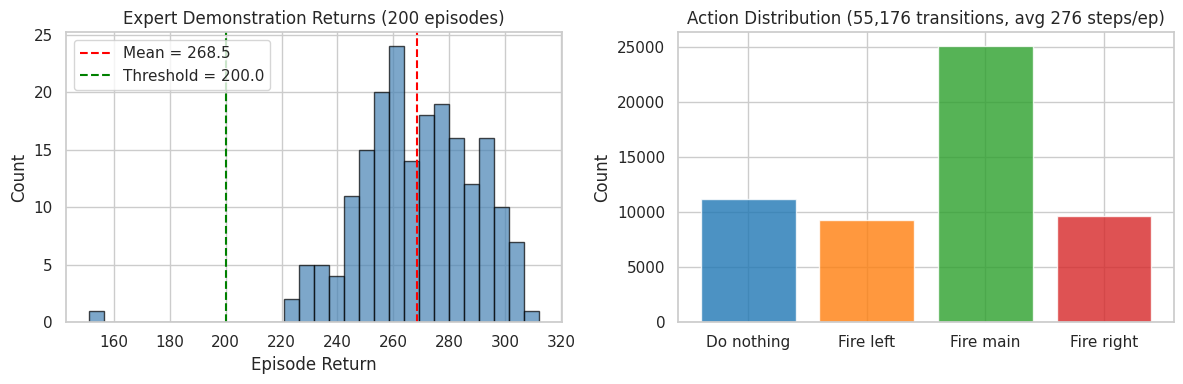

In [50]:
# Visualize the expert demonstration return distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Episode returns histogram
axes[0].hist(demo.episode_returns, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(demo.episode_returns), color='red', linestyle='--',
                label=f'Mean = {np.mean(demo.episode_returns):.1f}')
axes[0].axvline(THRESHOLD, color='green', linestyle='--', label=f'Threshold = {THRESHOLD}')
axes[0].set_xlabel('Episode Return')
axes[0].set_ylabel('Count')
axes[0].set_title('Expert Demonstration Returns (200 episodes)')
axes[0].legend()

# Episode lengths (inferred from transitions per episode)
ep_lengths = []
idx = 0
# We can estimate episode lengths from total transitions / episodes
avg_len = len(demo) / len(demo.episode_returns)
axes[1].bar(action_names, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8)
axes[1].set_ylabel('Count')
axes[1].set_title(f'Action Distribution ({len(demo):,} transitions, avg {avg_len:.0f} steps/ep)')

plt.tight_layout()
plt.show()

### 2.4 Behavioral Cloning

The `BehavioralCloning` trainer performs supervised learning on the demonstration dataset:

- **Loss**: Cross-entropy between predicted logits and expert actions.
- **Optimizer**: Adam with learning rate $10^{-3}$.
- **Early stopping**: Monitors validation loss with patience 10 (10% validation split).
- **Gradient clipping**: Max norm 1.0.
- **Data augmentation** (optional): Adds Gaussian noise $\mathcal{N}(0, \sigma^2)$ to observations during training (`noise_std` parameter), forcing the policy to learn recovery from perturbed states.

The key code for the noise augmentation mechanism:
```python
# In BehavioralCloning.train(), src/bc.py:
if cfg.noise_std > 0:
    obs = obs + torch.randn_like(obs) * cfg.noise_std
```

This simple line is the basis for Experiments 5 and 6, where we study how noise augmentation affects downstream RL performance.

---
<a id="3-experiment-1-main-comparison"></a>
## 3. Experiment 1: Main Comparison

**Question:** Does BC initialization help RL fine-tuning compared to training from scratch or using BC alone?

**Setup:** Three conditions, each run with 5 seeds:

| Condition | Description |
|-----------|-------------|
| **RL from scratch** | Random initialization → REINFORCE (2000 episodes) |
| **BC only** | Supervised learning on 200 expert episodes, no RL |
| **BC + REINFORCE** | BC initialization → REINFORCE fine-tuning (2000 episodes) |

**Hypothesis:** BC+REINFORCE should converge faster and achieve higher final performance than either BC alone or RL from scratch.

In [51]:
main_results = load_results("main_comparison.npy")

print("Main Comparison Results (5 seeds):")
print("=" * 55)
for cond, data in main_results.items():
    eval_mean = np.array(data["eval_mean"])
    eval_std = np.array(data["eval_std"])
    print(f"  {cond:15s}: final mean = {eval_mean[-1]:7.1f} +/- {eval_std[-1]:5.1f}")

Main Comparison Results (5 seeds):
  rl_scratch     : final mean =    86.1 +/-  73.0
  bc_only        : final mean =   262.2 +/-  29.3
  bc_reinforce   : final mean =   259.0 +/-  43.8


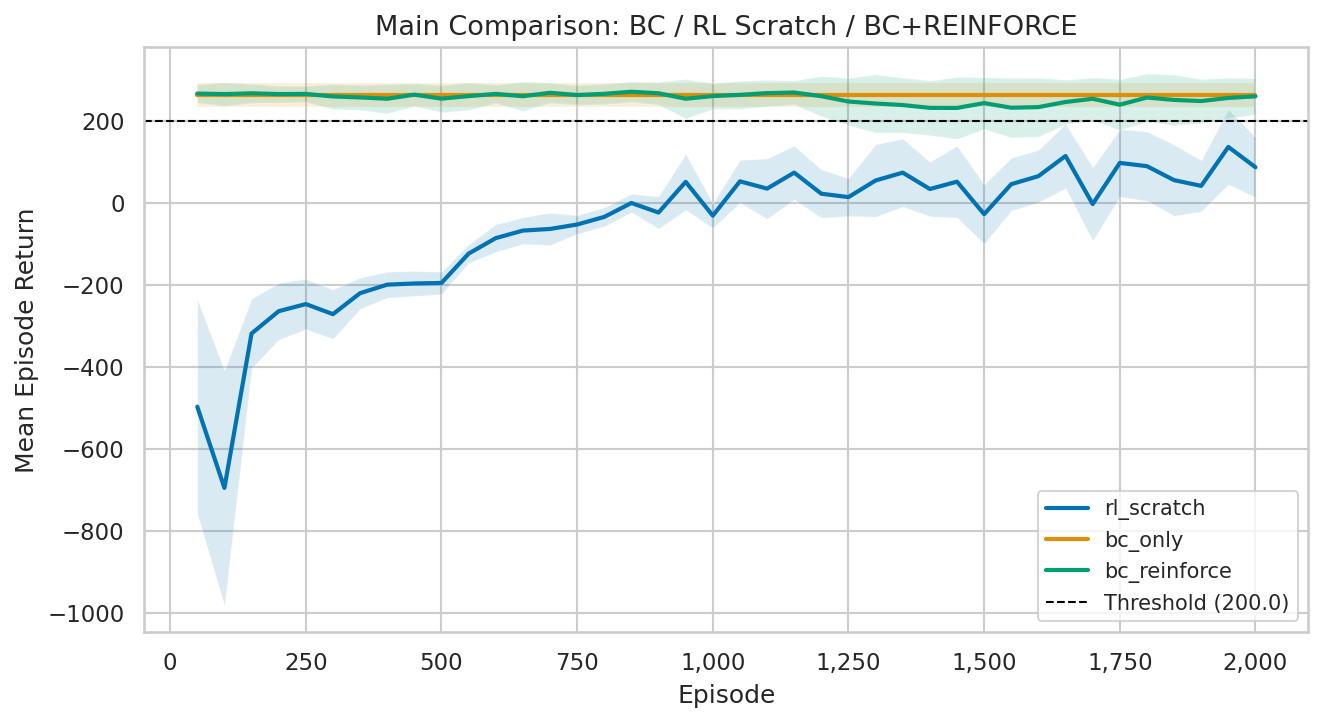

In [52]:
# Pre-generated learning curves
Image(filename=os.path.join(FIGURES_DIR, "main_comparison.png"), width=700)

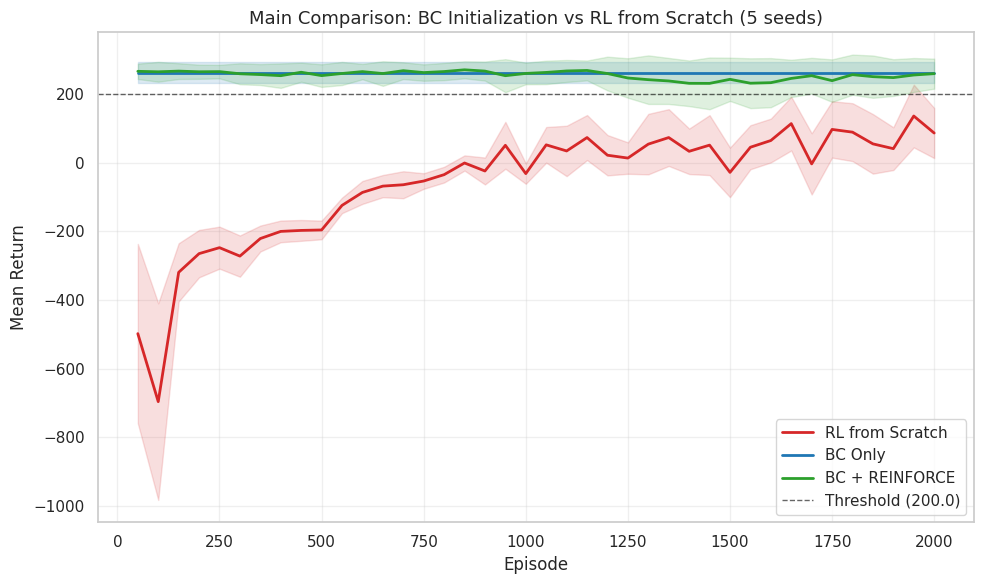

In [53]:
# Recreate the comparison plot from loaded data
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"rl_scratch": "#d62728", "bc_only": "#1f77b4", "bc_reinforce": "#2ca02c"}
labels = {"rl_scratch": "RL from Scratch", "bc_only": "BC Only", "bc_reinforce": "BC + REINFORCE"}

for cond, data in main_results.items():
    x = np.array(data["eval_at"])
    mean = np.array(data["eval_mean"])
    std = np.array(data["eval_std"])
    ax.plot(x, mean, label=labels.get(cond, cond), color=colors.get(cond, None), linewidth=2)
    ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=colors.get(cond, None))

ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Threshold ({THRESHOLD})")
ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Mean Return", fontsize=12)
ax.set_title("Main Comparison: BC Initialization vs RL from Scratch (5 seeds)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis

The results confirm the core hypothesis:

- **BC + REINFORCE** starts near the expert's performance (~266) and maintains high returns throughout training. The BC initialization provides a massive head start.
- **BC only** achieves a fixed performance (~262) with no ability to improve further — it is limited by covariate shift. (Since BC only has no RL, its "learning curve" is a flat line.)
- **RL from scratch** starts very poorly (~-498) and gradually improves over 2000 episodes, reaching ~86 — an improvement but still far below the BC-initialized agent.

The BC initialization provides an enormous head start: the BC+REINFORCE agent begins where RL-from-scratch would take many more episodes to reach. However, we also note that BC+REINFORCE's final performance (~259) is slightly below BC-only (~262) — in this particular setting with 200 expert demos, REINFORCE doesn't meaningfully improve over the already-strong BC policy. The main advantage is the fast start, not the final performance.

In [54]:
# Summary table
rows = []
for cond, data in main_results.items():
    label = {"rl_scratch": "RL from Scratch", "bc_only": "BC Only",
             "bc_reinforce": "BC + REINFORCE"}.get(cond, cond)
    rows.append({
        "Condition": label,
        "Initial Mean Return": f"{data['eval_mean'][0]:.1f}",
        "Final Mean Return": f"{data['eval_mean'][-1]:.1f}",
        "Final Std": f"{data['eval_std'][-1]:.1f}",
    })
df = pd.DataFrame(rows)
display(df.style.hide(axis='index'))

Condition,Initial Mean Return,Final Mean Return,Final Std
RL from Scratch,-497.9,86.1,73.0
BC Only,262.2,262.2,29.3
BC + REINFORCE,265.8,259.0,43.8


---
<a id="4-experiment-2-demo-size-ablation"></a>
## 4. Experiment 2: Demonstration Dataset Size Ablation

**Question:** How does the number of demonstration episodes affect BC quality and the benefit of RL fine-tuning?

**Setup:** Demonstration dataset sizes $N \in \{100, 500, 1000, 2000\}$. For each $N$: train BC, evaluate BC-only performance, then fine-tune with REINFORCE (1500 episodes). 5 seeds per condition.

**Hypothesis:** RL fine-tuning provides the largest improvement when demonstration data is scarce (larger covariate shift to correct).

In [55]:
demo_size_results = load_results("demo_size_ablation.npy")

print("Demo Size Ablation Results:")
print("=" * 70)
print(f"{'N':>6} | {'BC Only Mean':>12} | {'BC Only Std':>11} | {'BC+RL Final':>12} | {'RL Uplift':>10}")
print("-" * 70)
for n in sorted(demo_size_results.keys()):
    data = demo_size_results[n]
    bc_mean = data["bc_only_mean"]
    bc_std = data["bc_only_std"]
    rl_final = data["eval_mean"][-1]
    uplift = rl_final - bc_mean
    print(f"{n:>6} | {bc_mean:>12.1f} | {bc_std:>11.1f} | {rl_final:>12.1f} | {uplift:>+10.1f}")

Demo Size Ablation Results:
     N | BC Only Mean | BC Only Std |  BC+RL Final |  RL Uplift
----------------------------------------------------------------------
   100 |       -519.7 |       184.7 |         -4.6 |     +515.1
   500 |        222.8 |        12.7 |        126.7 |      -96.0
  1000 |        259.9 |         5.1 |        119.5 |     -140.4
  2000 |        259.8 |         2.1 |        139.0 |     -120.7


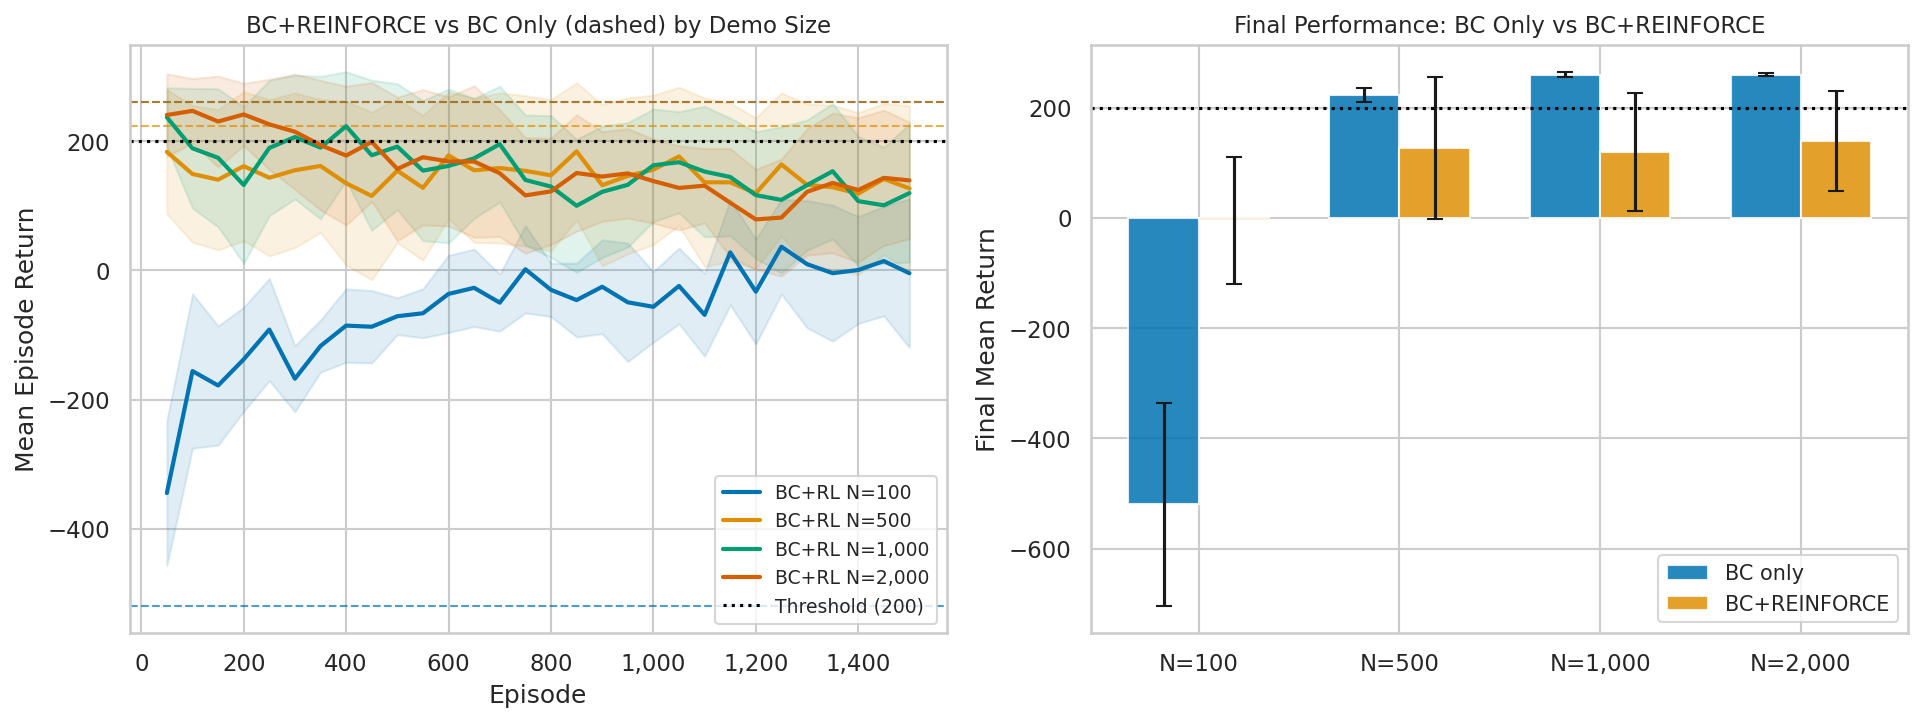

In [56]:
# Pre-generated figure
Image(filename=os.path.join(FIGURES_DIR, "demo_size_ablation.png"), width=800)

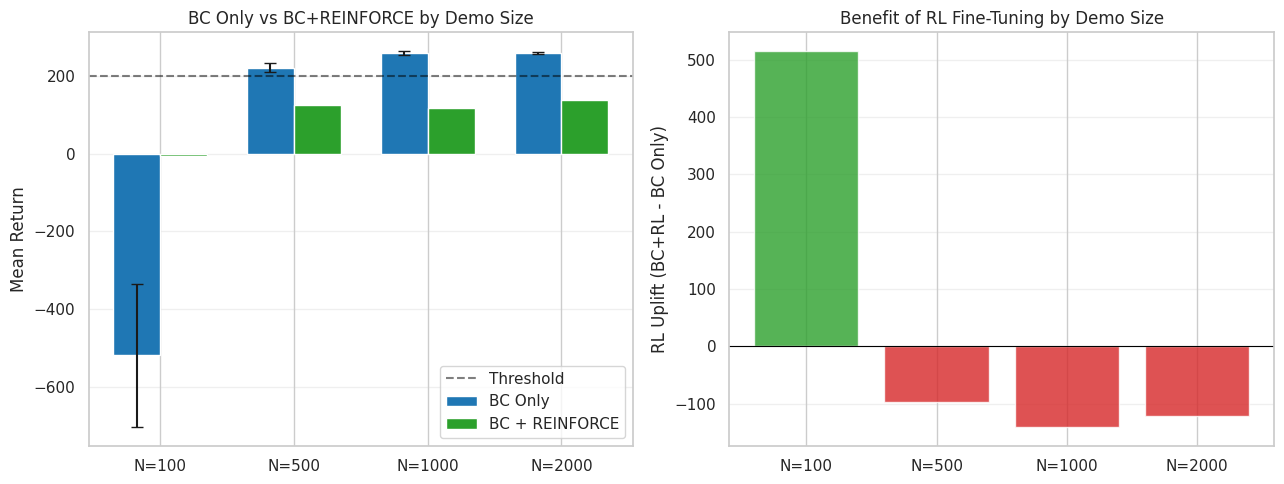

In [57]:
# Visualize the RL uplift by demo size
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ns = sorted(demo_size_results.keys())
bc_means = [demo_size_results[n]["bc_only_mean"] for n in ns]
bc_stds = [demo_size_results[n]["bc_only_std"] for n in ns]
rl_finals = [demo_size_results[n]["eval_mean"][-1] for n in ns]
uplifts = [rl - bc for rl, bc in zip(rl_finals, bc_means)]

# Left: BC-only vs BC+RL final performance
x = np.arange(len(ns))
width = 0.35
axes[0].bar(x - width/2, bc_means, width, yerr=bc_stds, label='BC Only', capsize=4, color='#1f77b4')
axes[0].bar(x + width/2, rl_finals, width, label='BC + REINFORCE', capsize=4, color='#2ca02c')
axes[0].axhline(THRESHOLD, color='black', linestyle='--', alpha=0.5, label='Threshold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'N={n}' for n in ns])
axes[0].set_ylabel('Mean Return')
axes[0].set_title('BC Only vs BC+REINFORCE by Demo Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Right: RL uplift
colors = ['#d62728' if u < 0 else '#2ca02c' for u in uplifts]
axes[1].bar(range(len(ns)), uplifts, tick_label=[f'N={n}' for n in ns], color=colors, alpha=0.8)
axes[1].set_ylabel('RL Uplift (BC+RL - BC Only)')
axes[1].set_title('Benefit of RL Fine-Tuning by Demo Size')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Analysis

- **BC-only performance scales with data**: With 100 demos, BC achieves very poor performance (worse than random); with 1000+ demos, it reaches ~260, well above the 200 threshold.
- **RL fine-tuning helps most when BC is weakest**: At N=100, RL dramatically improves over the terrible BC-only baseline. However, at N≥500, REINFORCE fine-tuning (1500 episodes) actually **degrades** performance below BC-only — the bar chart above shows negative RL uplift for these conditions.
- **Why does RL hurt at high N?** When BC is already good (N≥500, mean return >200), REINFORCE's high-variance policy gradient updates can destabilize the policy. With only 1500 episodes of fine-tuning, the agent may not recover from this initial degradation. This highlights a real risk of RL fine-tuning: it can *hurt* a good initialization if the training budget or algorithm is not carefully chosen.
- **Diminishing returns for BC**: Beyond ~1000 demos, BC performance plateaus and additional data provides minimal benefit.

This experiment reveals an important nuance: BC+RL is not universally better than BC alone. The benefit depends on the quality of the BC initialization and the stability of the RL algorithm used for fine-tuning.

---
<a id="5-experiment-3-expert-quality-ablation"></a>
## 5. Experiment 3: Expert Quality Ablation

**Question:** How does the quality of the expert policy affect BC and subsequent RL fine-tuning?

**Setup:** We use expert checkpoints at three stages of training:
- **50k steps** (weak expert — still learning)
- **200k steps** (mid-quality expert)
- **500k steps** (fully trained expert, best model)

For each, we collect 200 episodes of demonstrations, train BC, then fine-tune with REINFORCE (1500 episodes). 5 seeds.

In [58]:
expert_quality_results = load_results("expert_quality_ablation.npy")

print("Expert Quality Ablation Results:")
print("=" * 55)
for label, data in expert_quality_results.items():
    init = data["eval_mean"][0]
    final = data["eval_mean"][-1]
    print(f"  {label:20s}: init = {init:7.1f},  final = {final:7.1f}")

Expert Quality Ablation Results:
  50k steps (weak)    : init =  -241.7,  final =  -172.2
  200k steps (mid)    : init =   240.2,  final =   192.4
  500k steps (full)   : init =   264.0,  final =   208.8


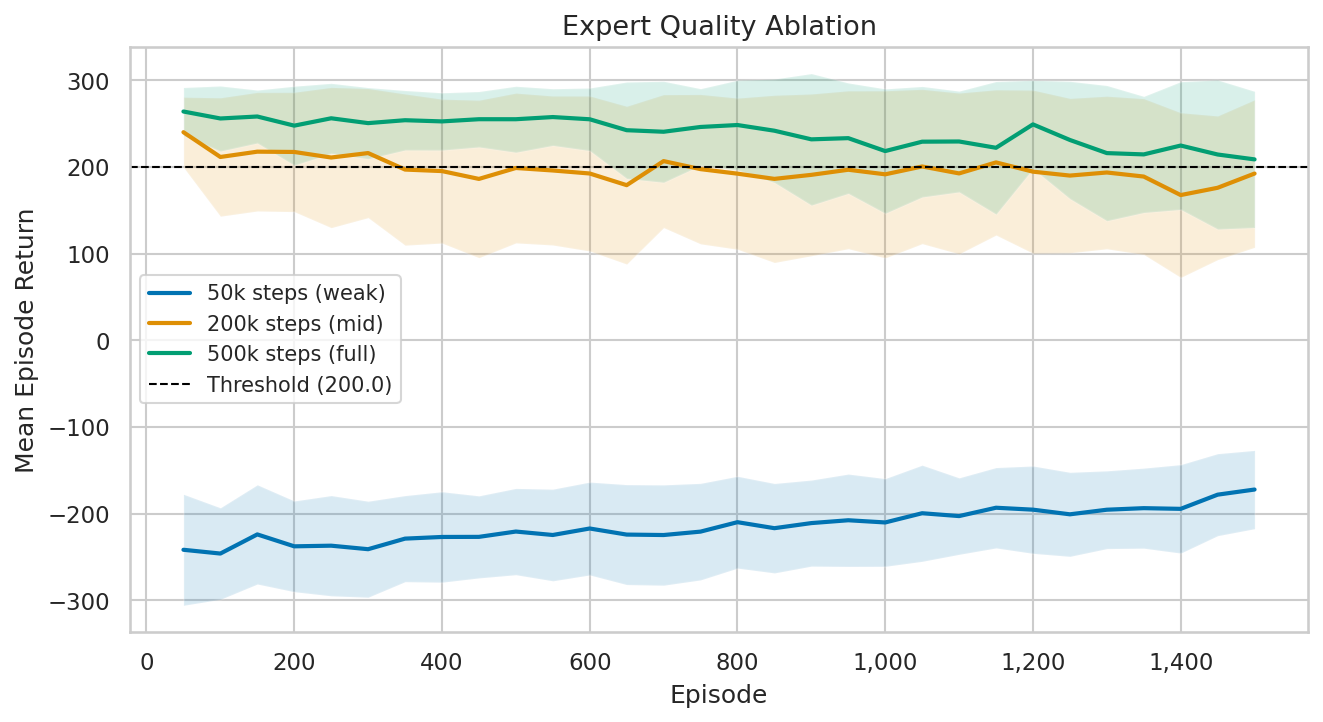

In [59]:
# Pre-generated figure
Image(filename=os.path.join(FIGURES_DIR, "expert_quality_ablation.png"), width=700)

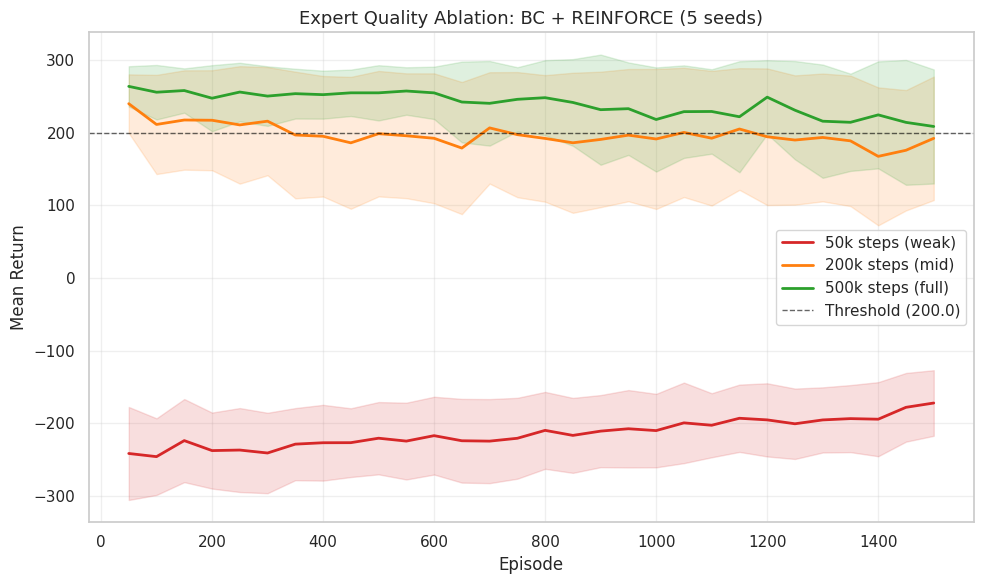

In [60]:
# Recreate learning curves from loaded data
fig, ax = plt.subplots(figsize=(10, 6))
colors_eq = ["#d62728", "#ff7f0e", "#2ca02c"]

for i, (label, data) in enumerate(expert_quality_results.items()):
    x = np.array(data["eval_at"])
    mean = np.array(data["eval_mean"])
    std = np.array(data["eval_std"])
    ax.plot(x, mean, label=label, color=colors_eq[i], linewidth=2)
    ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=colors_eq[i])

ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Threshold ({THRESHOLD})")
ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Mean Return", fontsize=12)
ax.set_title("Expert Quality Ablation: BC + REINFORCE (5 seeds)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis

- **Better expert → better BC → faster RL convergence**: The 500k-step expert provides high-quality demonstrations that lead to a strong BC initialization, which in turn enables the best RL fine-tuning outcome.
- **Mid-quality expert (200k) performs nearly as well**: The 200k expert already provides demonstrations good enough for a strong BC initialization, achieving final performance close to the 500k expert.
- **Weak expert (50k steps) does not recover**: Starting from a poor BC initialization (mean return ~-242), REINFORCE fine-tuning over 1500 episodes improves but does not reach positive returns within the training budget. This suggests that RL fine-tuning cannot fully compensate for a very weak starting point — the BC initialization must be at least reasonable for fine-tuning to succeed.

This confirms that expert quality matters most for the initial BC performance, and while RL can partially compensate for suboptimal demonstrations, a minimum quality threshold exists below which fine-tuning struggles.

---
<a id="6-experiment-4-bc--ppo-fine-tuning"></a>
## 6. Experiment 4: BC + PPO Fine-Tuning and Entropy Annealing

**Question:** Can PPO, a more sophisticated RL algorithm, improve over REINFORCE for fine-tuning? Does entropy annealing help stabilize PPO after BC initialization?

### Motivation

REINFORCE has high variance because it uses full episode returns. PPO (Proximal Policy Optimization) is generally more sample-efficient due to its clipped surrogate objective and minibatch updates. However, after BC pretraining the policy is already concentrated (low entropy), which may cause PPO to under-explore.

**Entropy annealing** addresses this by starting with a higher entropy coefficient ($0.02$) to encourage initial exploration, then linearly decreasing to $0.001$ over training:

$$\text{ent\_coef}(t) = \text{start\_ent} \cdot (1 - \text{progress}) + \text{end\_ent} \cdot \text{progress}$$

### Weight Transfer Challenge

Transferring BC weights from our custom `PolicyNetwork` to SB3's PPO requires matching layer shapes. The `transfer_bc_weights_to_ppo()` function performs shape-matching to copy weights from the BC network to the PPO policy network. A critical implementation detail: PPO must be configured with `policy_kwargs={"net_arch": [256, 256]}` to match BC's hidden dimensions.

In [61]:
# Show the weight transfer function
# NOTE: We read the file directly instead of importing, because
# bc_ppo_finetune.py has no if __name__ == '__main__' guard and
# importing it would re-run the entire training pipeline.
import re as _re

with open('src/bc_ppo_finetune.py') as f:
    _source = f.read()

# Extract the transfer function
_match = _re.search(r'(def transfer_bc_weights_to_ppo\b.*?)(?=\ndef \w|\n# -{5}|$)', _source, _re.DOTALL)
if _match:
    print(_match.group(1).rstrip())
else:
    print('Function not found — check src/bc_ppo_finetune.py')

def transfer_bc_weights_to_ppo(bc_policy, ppo_model):
    """
    Copy BC network weights into the PPO policy network.
    """

    bc_state = bc_policy.state_dict()

    ppo_state = ppo_model.policy.state_dict()

    matched = []

    for name, param in ppo_state.items():
        for bc_name, bc_param in bc_state.items():
            if param.shape == bc_param.shape:
                ppo_state[name] = bc_param.detach().cpu()
                matched.append((name, bc_name))
                break

    ppo_model.policy.load_state_dict(ppo_state)

    print(f"Transferred {len(matched)} layers from BC → PPO")


In [62]:
# Show the entropy annealing callback (safe to import — pure class, no side effects)
import inspect
from src.entropy_annealing_callback import EntropyAnnealingCallback
print(inspect.getsource(EntropyAnnealingCallback))

class EntropyAnnealingCallback(BaseCallback):
    """
    Linearly anneals PPO entropy coefficient during training.

    ent_coef(t) = start_ent * (1 - progress) + end_ent * progress
    where progress ∈ [0,1]
    """

    def __init__(self, start_ent: float = 0.02, end_ent: float = 0.001, verbose=0):
        super().__init__(verbose)
        self.start_ent = start_ent
        self.end_ent = end_ent

    def _on_training_start(self) -> None:
        self.total_timesteps = self.model._total_timesteps

    def _on_step(self) -> bool:
        progress = self.num_timesteps / self.total_timesteps

        new_entropy = self.start_ent * (1 - progress) + self.end_ent * progress

        # Update PPO entropy coefficient
        self.model.ent_coef = new_entropy

        if self.verbose > 0 and self.num_timesteps % 50000 == 0:
            print(f"Entropy coef updated → {new_entropy:.6f}")

        return True



In [63]:
# Load results
ppo_results = load_results("bc_ppo_results.npy")
annealing_results = load_results("bc_ppo_annealing.npy")

print("BC + PPO Fine-Tuning Results:")
print("=" * 50)
print(f"  BC Only:                {ppo_results['bc']['mean']:7.1f} +/- {ppo_results['bc']['std']:.1f}")
print(f"  BC + PPO (500k steps):  {ppo_results['ppo']['mean']:7.1f} +/- {ppo_results['ppo']['std']:.1f}")
print(f"  BC + PPO + Annealing:   {annealing_results['ppo_annealing']['mean']:7.1f} +/- {annealing_results['ppo_annealing']['std']:.1f}")

BC + PPO Fine-Tuning Results:
  BC Only:                  230.8 +/- 62.6
  BC + PPO (500k steps):    235.2 +/- 47.2
  BC + PPO + Annealing:     245.4 +/- 71.8


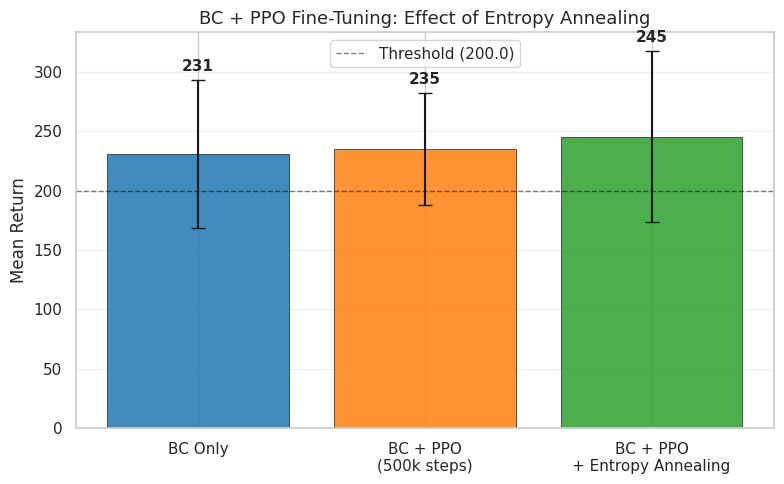

In [64]:
# Bar chart comparing all three conditions
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["BC Only", "BC + PPO\n(500k steps)", "BC + PPO\n+ Entropy Annealing"]
means = [
    ppo_results["bc"]["mean"],
    ppo_results["ppo"]["mean"],
    annealing_results["ppo_annealing"]["mean"]
]
stds = [
    ppo_results["bc"]["std"],
    ppo_results["ppo"]["std"],
    annealing_results["ppo_annealing"]["std"]
]
bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

bars = ax.bar(labels, means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1, alpha=0.5, label=f"Threshold ({THRESHOLD})")
ax.set_ylabel("Mean Return", fontsize=12)
ax.set_title("BC + PPO Fine-Tuning: Effect of Entropy Annealing", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# Annotate bars with values
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 5,
            f'{m:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Analysis

The results above show that PPO fine-tuning provides only a marginal change over BC-only performance — the differences are within error bars. Entropy annealing yields a slightly higher mean return by encouraging initial exploration before converging, but the improvement is modest.

The relatively small gains from PPO fine-tuning in this setting may be because the BC policy (trained on 200 expert episodes) is already quite good, leaving limited room for improvement. The high standard deviations also suggest that a single-seed evaluation (as used here) is not sufficient for strong conclusions — multi-seed experiments would be needed for reliable comparison.

**Implementation notes:**
- SB3's PPO MlpPolicy runs more efficiently on CPU than GPU for non-CNN policies.
- `EvalCallback` only records `evaluations_results` / `evaluations_timesteps` when `log_path` is provided.
- The PPO `net_arch` must be set to `[256, 256]` to match the BC `PolicyNetwork` hidden dims for correct weight transfer.

---
<a id="7-experiment-5-observation-noise-augmentation"></a>
## 7. Experiment 5: Observation Noise Augmentation

**Question:** Does adding Gaussian noise to observations during BC training reduce covariate shift and improve downstream RL fine-tuning?

### Motivation

Standard BC trains only on expert-visited states. By adding noise $\tilde{s} = s + \mathcal{N}(0, \sigma^2 I)$ during training, we force the policy to learn correct actions for *perturbed* states near the expert trajectory. This implicitly broadens the training distribution and teaches the policy to recover from small deviations — directly mitigating covariate shift.

### Experiment V1: Binary Comparison ($\sigma = 0$ vs $\sigma = 0.1$)

The first experiment compared plain BC ($\sigma = 0$) vs augmented BC ($\sigma = 0.1$) → REINFORCE, using 500 demo transitions and 5 seeds.

In [65]:
aug_v1 = load_results("bc_aug_results.npy")

print("BC Augmentation V1 Results (5 seeds):")
print("=" * 65)
for label, tag in [("plain", "No augmentation (sigma=0.0)"), ("aug", "Augmented (sigma=0.1)")]:
    data = aug_v1[label]
    print(f"\n  {tag}:")
    print(f"    BC score:         {np.mean(data['bc_mean']):7.1f} +/- {np.std(data['bc_mean']):.1f}")
    print(f"    Covariate shift:  {np.mean(data['shift']):.4f}")
    print(f"    REINFORCE final:  {np.mean(data['rl_final_mean']):7.1f} +/- {np.std(data['rl_final_mean']):.1f}")

BC Augmentation V1 Results (5 seeds):

  No augmentation (sigma=0.0):
    BC score:           -37.6 +/- 301.8
    Covariate shift:  0.7450
    REINFORCE final:     56.1 +/- 55.0

  Augmented (sigma=0.1):
    BC score:          -204.1 +/- 189.2
    Covariate shift:  0.8776
    REINFORCE final:    101.4 +/- 68.5


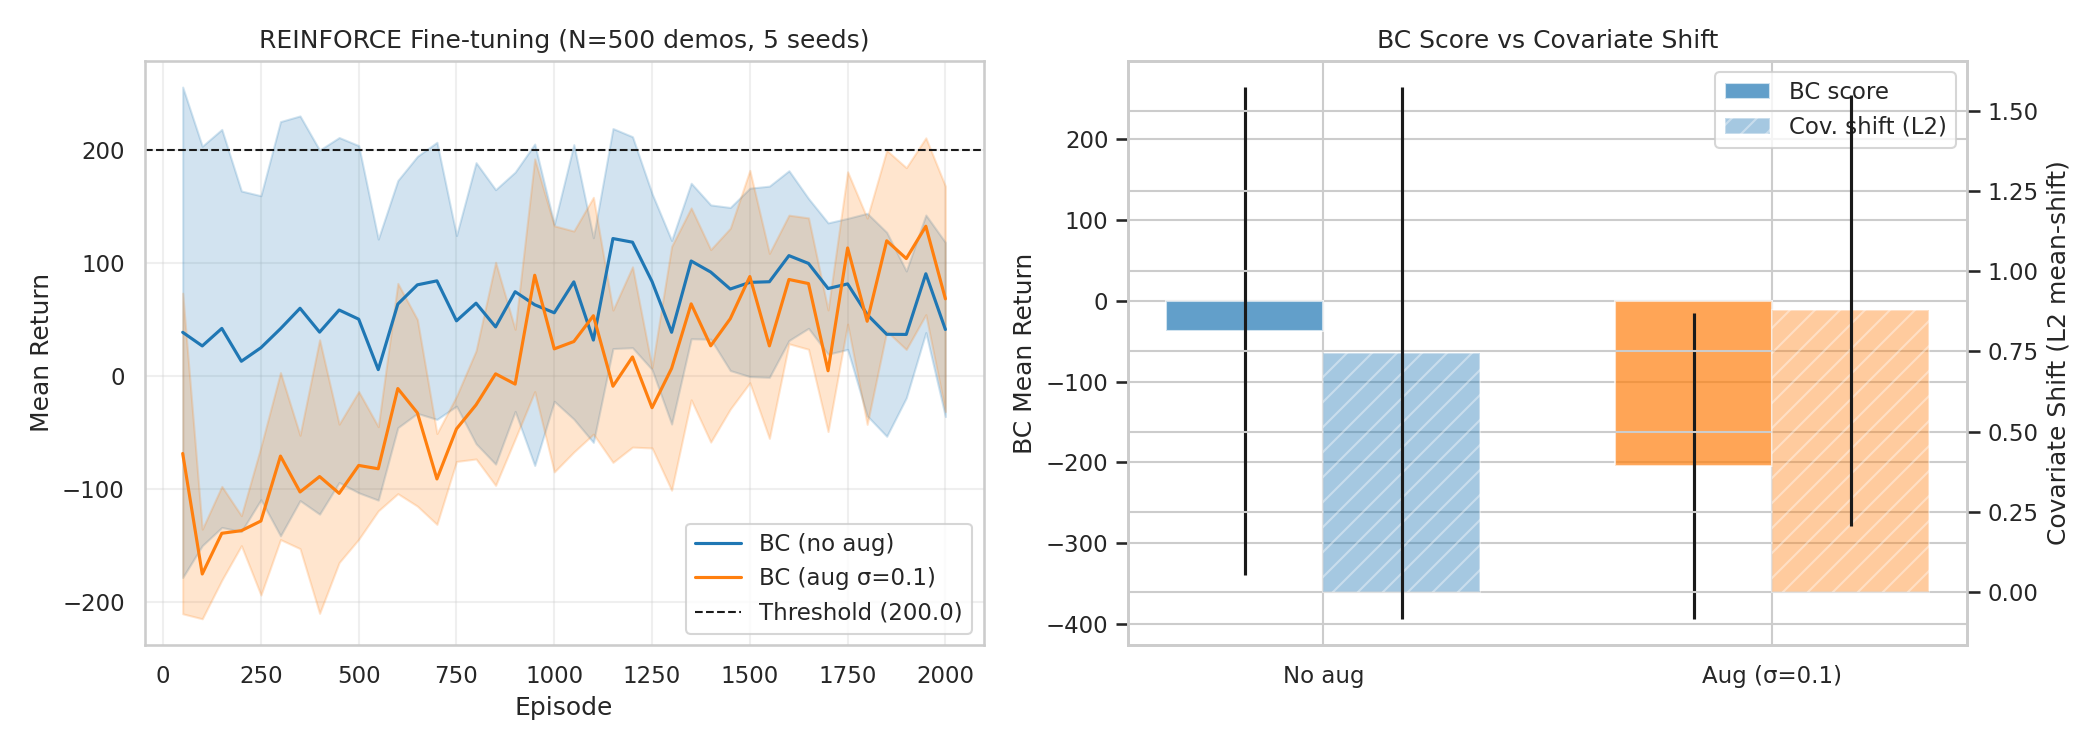

In [66]:
# Pre-generated V1 figure
Image(filename=os.path.join(FIGURES_DIR, "bc_aug_comparison.png"), width=800)

**V1 Key Finding:** Augmented BC ($\sigma = 0.1$) improves REINFORCE final return (mean across 5 seeds: ~56 → ~101, an ~80% improvement). This comes at a cost: the augmented BC-only score is noticeably worse than plain BC, because the added noise during training degrades the supervised learning accuracy. However, the benefit manifests during RL fine-tuning — the augmented policy has learned to handle perturbed states, giving REINFORCE a better foundation for improvement.

Note that high per-seed variance is present in this experiment (see the printed values above), so these findings should be interpreted cautiously.

### Experiment V2: Systematic Sigma Sweep

Building on V1, we performed a comprehensive sweep over $\sigma \in \{0.0, 0.05, 0.1, 0.2\}$, testing both REINFORCE (5000 episodes) and PPO (100k steps). 5 seeds per condition.

> **Note:** The V2 experiment took ~22 hours to complete and was run offline. Results were checkpointed incrementally.

In [67]:
aug_v2 = load_results("bc_aug_v2_results.npy")

NOISE_STDS = [0.0, 0.05, 0.1, 0.2]

print("BC Augmentation V2 Results (5 seeds):")
print("=" * 80)
print(f"{'sigma':>6} | {'BC Score':>10} | {'Cov Shift':>10} | {'REINFORCE Final':>16} | {'PPO Final':>10}")
print("-" * 80)
for sigma in NOISE_STDS:
    key = f"sigma_{sigma}"
    r = aug_v2[key]
    print(f"{sigma:>6.2f} | {np.mean(r['bc_mean']):>10.1f} | {np.mean(r['shift']):>10.4f} | "
          f"{np.mean(r['reinforce_final_mean']):>16.1f} | {np.mean(r['ppo_final_mean']):>10.1f}")

BC Augmentation V2 Results (5 seeds):
 sigma |   BC Score |  Cov Shift |  REINFORCE Final |  PPO Final
--------------------------------------------------------------------------------
  0.00 |      -20.5 |     0.7459 |            155.3 |      191.5
  0.05 |     -130.4 |     0.8842 |            190.5 |      111.5
  0.10 |     -209.1 |     0.8873 |            150.3 |       39.8
  0.20 |     -339.6 |     1.2901 |            166.2 |       40.4


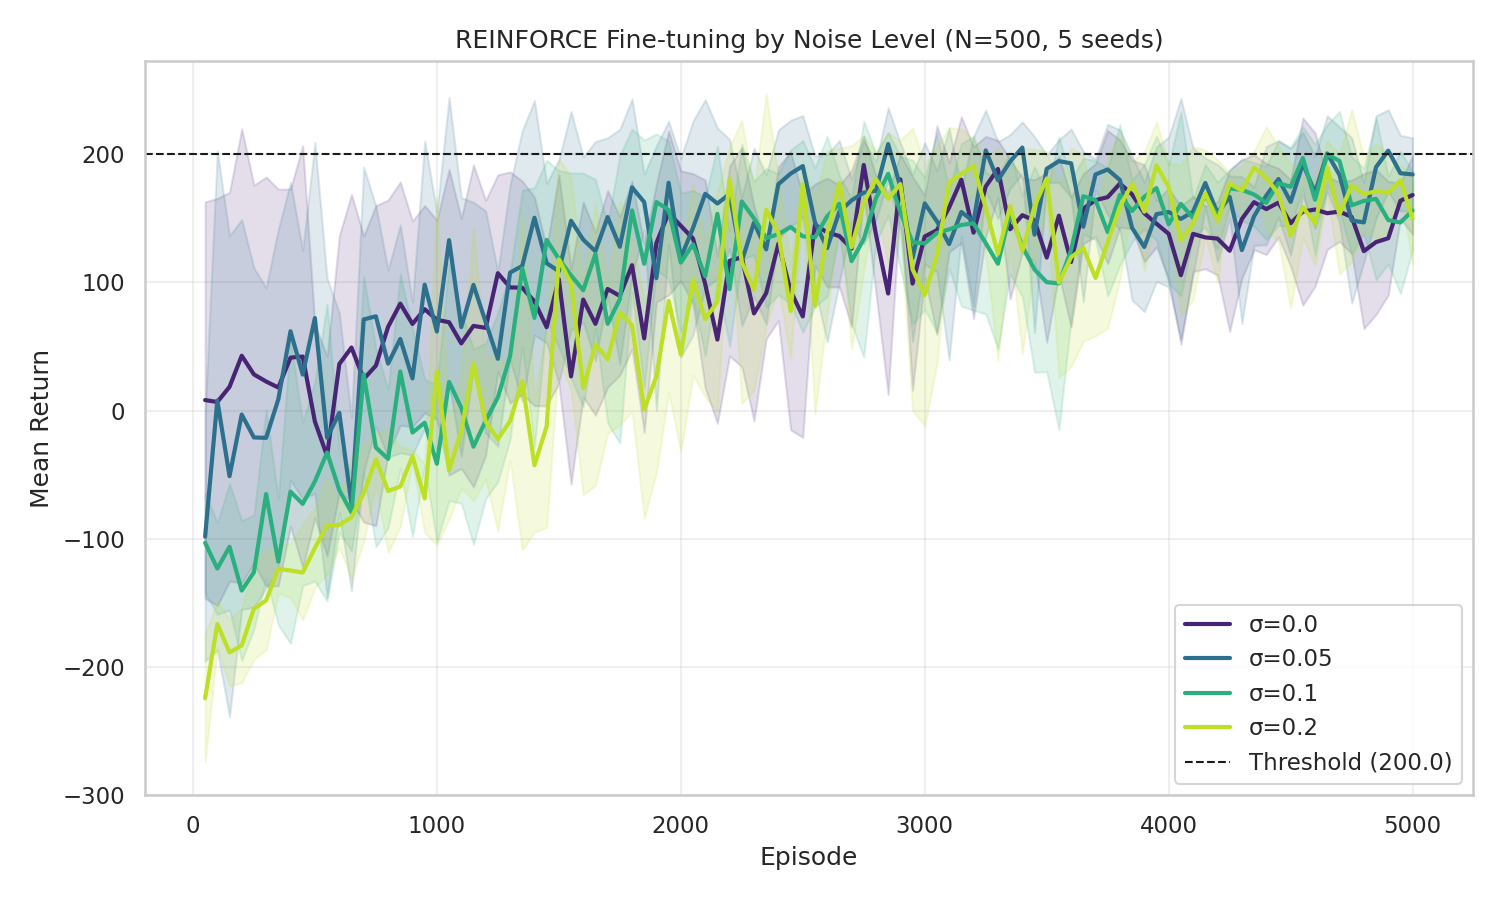

In [68]:
# V2 REINFORCE learning curves
Image(filename=os.path.join(FIGURES_DIR, "bc_aug_v2_reinforce_curves.png"), width=750)

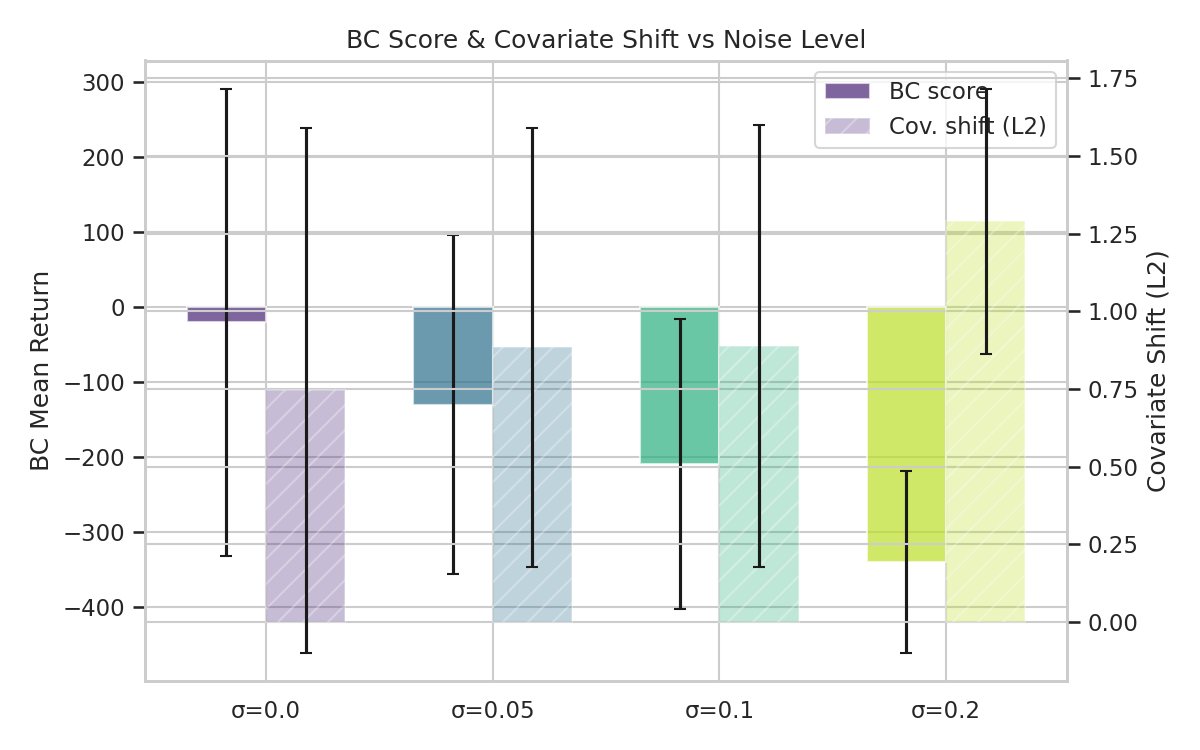

In [69]:
# BC score and covariate shift analysis
Image(filename=os.path.join(FIGURES_DIR, "bc_aug_v2_bc_shift.png"), width=700)

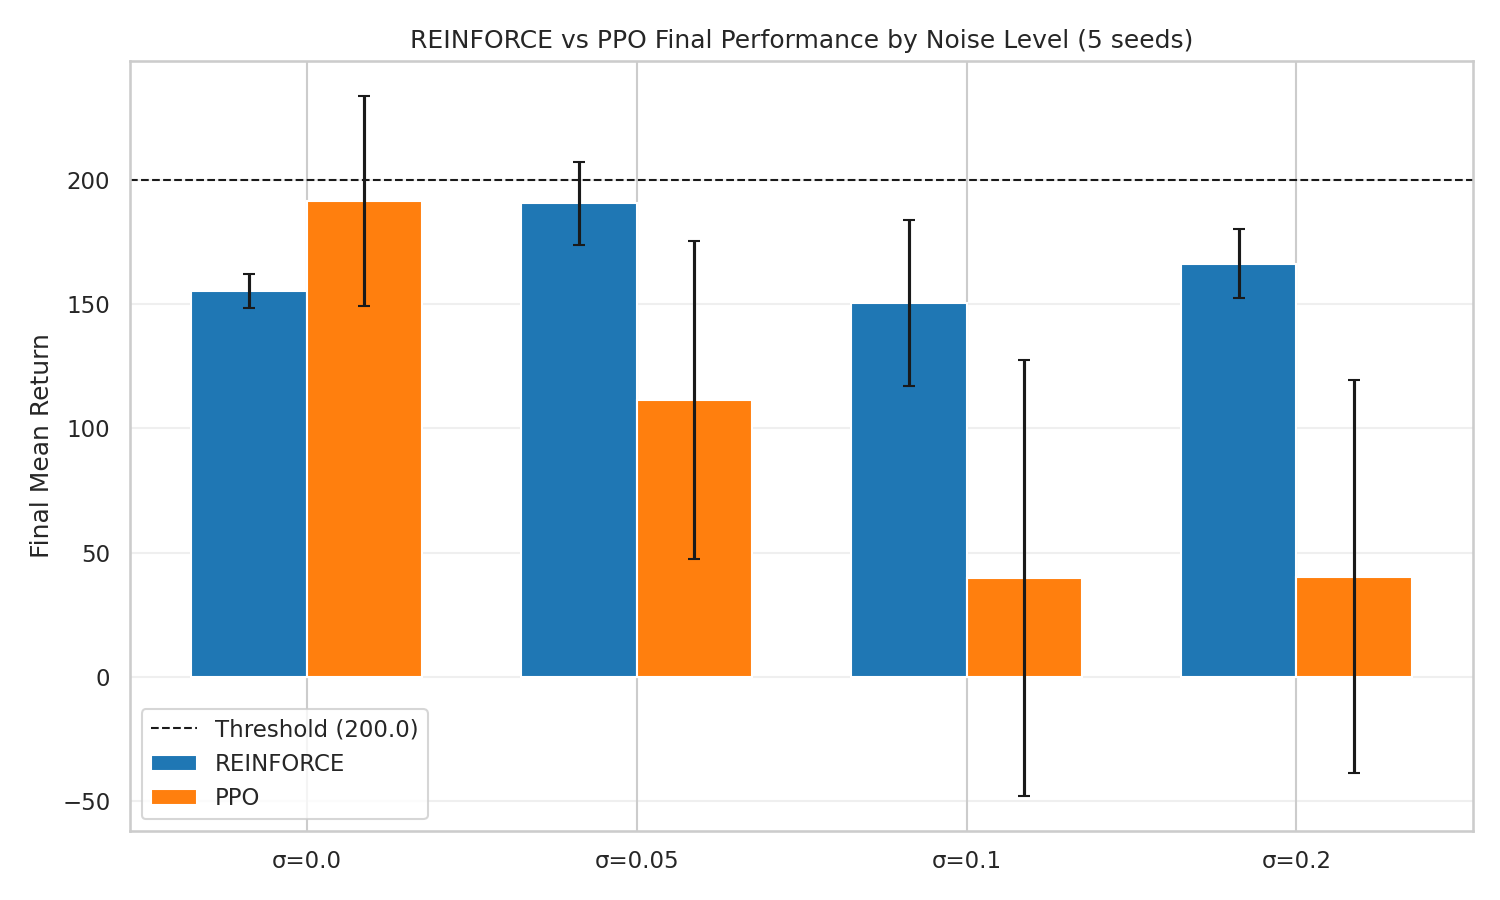

In [70]:
# final performance comparison
Image(filename=os.path.join(FIGURES_DIR, "bc_aug_v2_final_comparison.png"), width=700)

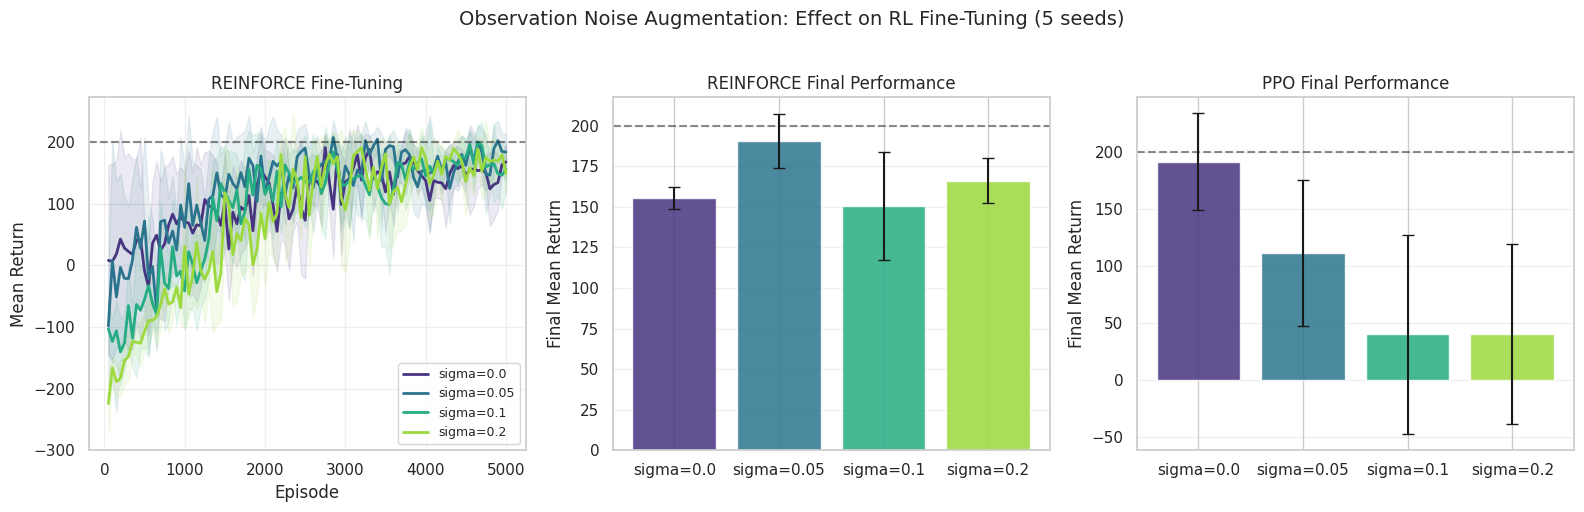

In [71]:
# Recreate a combined visualization from the loaded data
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_sigma = plt.cm.viridis(np.linspace(0.15, 0.85, len(NOISE_STDS)))

# Panel 1: REINFORCE learning curves
for i, sigma in enumerate(NOISE_STDS):
    key = f"sigma_{sigma}"
    curves = np.array(aug_v2[key]["reinforce_curves"])
    x = np.array(aug_v2[key]["reinforce_eval_at"])
    mean = curves.mean(axis=0)
    std = curves.std(axis=0)
    axes[0].plot(x, mean, label=f"sigma={sigma}", color=colors_sigma[i], linewidth=2)
    axes[0].fill_between(x, mean - std, mean + std, alpha=0.1, color=colors_sigma[i])
axes[0].axhline(THRESHOLD, color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Mean Return")
axes[0].set_title("REINFORCE Fine-Tuning")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Final REINFORCE performance
reinforce_finals = [np.mean(aug_v2[f"sigma_{s}"]["reinforce_final_mean"]) for s in NOISE_STDS]
reinforce_stds = [np.std(aug_v2[f"sigma_{s}"]["reinforce_final_mean"]) for s in NOISE_STDS]
axes[1].bar(range(len(NOISE_STDS)), reinforce_finals, yerr=reinforce_stds,
            tick_label=[f"sigma={s}" for s in NOISE_STDS], color=colors_sigma, capsize=4, alpha=0.85)
axes[1].axhline(THRESHOLD, color='k', linestyle='--', alpha=0.5)
axes[1].set_ylabel("Final Mean Return")
axes[1].set_title("REINFORCE Final Performance")
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: PPO final performance
ppo_finals = [np.mean(aug_v2[f"sigma_{s}"]["ppo_final_mean"]) for s in NOISE_STDS]
ppo_stds = [np.std(aug_v2[f"sigma_{s}"]["ppo_final_mean"]) for s in NOISE_STDS]
axes[2].bar(range(len(NOISE_STDS)), ppo_finals, yerr=ppo_stds,
            tick_label=[f"sigma={s}" for s in NOISE_STDS], color=colors_sigma, capsize=4, alpha=0.85)
axes[2].axhline(THRESHOLD, color='k', linestyle='--', alpha=0.5)
axes[2].set_ylabel("Final Mean Return")
axes[2].set_title("PPO Final Performance")
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle("Observation Noise Augmentation: Effect on RL Fine-Tuning (5 seeds)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Analysis

**REINFORCE results:**
- REINFORCE is **robust** across all noise levels, achieving 150–191 mean final return across $\sigma$ values (as shown in the table and plots above).
- $\sigma = 0.05$ yields the best average REINFORCE performance (~191).
- Higher noise ($\sigma = 0.2$) slightly degrades performance but REINFORCE still converges well (~166).

**PPO results:**
- PPO performance **degrades as noise increases**: at $\sigma = 0$, PPO achieves ~192; at $\sigma = 0.05$ it drops to ~112; and at $\sigma \geq 0.1$ it falls further (see the table above for exact values).
- This is a surprising and important finding: PPO's own clipped objective and exploration mechanism apparently conflict with the broader state distribution induced by noise augmentation. The higher the noise, the worse PPO performs.

**Covariate shift:**
- The covariate shift metric (L2 mean-shift) shows complex behavior across noise levels (see the printed table). The shift does not monotonically decrease with noise — the relationship depends on which seeds are examined, and per-seed variance is high.
- At $\sigma = 0.2$, the shift metric actually increases, likely because the added noise pushes the BC policy too far from expert-like behavior.

**Key takeaway:** Observation noise augmentation is a simple and effective technique for improving REINFORCE fine-tuning, but the optimal noise level depends on the downstream RL algorithm. REINFORCE is robust to augmentation noise, while PPO is sensitive and degrades with increasing noise.

---
<a id="8-experiment-6-rl-method-comparison"></a>
## 8. Experiment 6: RL Method Comparison — REINFORCE vs A2C vs PPO

**Question:** Which RL algorithm extracts the most value from BC initialization? Does augmentation help all methods equally?

**Setup:** Three RL fine-tuning methods tested under two BC conditions:

| Method | Training Budget | Update Style |
|--------|----------------|-------------|
| **REINFORCE** | 5000 episodes | Episode-level, learned value baseline |
| **A2C** | 500k steps | n-step online (n=5), RMSprop, shared trunk |
| **PPO** | 100k steps | Minibatch, clipped surrogate objective |

Two BC conditions: plain ($\sigma = 0.0$) and augmented ($\sigma = 0.1$). 5 seeds.

### Weight Transfer to A2C

Transferring BC weights to the `ActorCriticNetwork` (used by A2C) is more delicate than for REINFORCE or PPO. The trunk and actor head layers share the same hidden dimension (256), so shape-matching is ambiguous. Instead, we use explicit layer-name mapping:

In [72]:
# Show the explicit weight mapping function for A2C
# NOTE: We read the file directly because bc_method_comparison.py
# has no if __name__ == '__main__' guard.
import re as _re

with open('src/bc_method_comparison.py') as f:
    _source = f.read()

_match = _re.search(r'(def bc_weights_to_ac\b.*?)(?=\ndef \w|\nclass \w|\n# -{5}|$)', _source, _re.DOTALL)
if _match:
    print(_match.group(1).rstrip())
else:
    print('Function not found — check src/bc_method_comparison.py')

def bc_weights_to_ac(bc_policy: PolicyNetwork) -> ActorCriticNetwork:
    """
    Copy BC PolicyNetwork actor weights into a new ActorCriticNetwork.

    PolicyNetwork layout (hidden_dims=[256,256]):
      net.0  Linear(8→256),  net.2  Linear(256→256),  net.4  Linear(256→4)

    ActorCriticNetwork layout (hidden_dims=[256,256]):
      trunk.0  Linear(8→256)
      actor_head.0  Linear(256→256),  actor_head.2  Linear(256→4)
      critic_head.*  (random init — BC has no value function)
    """
    ac = ActorCriticNetwork(OBS_DIM, ACT_DIM)
    bc_sd = bc_policy.state_dict()
    ac_sd = ac.state_dict()
    mapping = {
        "trunk.0.weight":      "net.0.weight",
        "trunk.0.bias":        "net.0.bias",
        "actor_head.0.weight": "net.2.weight",
        "actor_head.0.bias":   "net.2.bias",
        "actor_head.2.weight": "net.4.weight",
        "actor_head.2.bias":   "net.4.bias",
    }
    for ac_key, bc_key in mapping.items():
        ac_sd[ac_key] = bc_sd[bc_key].clone()
    ac.l

In [73]:
method_results = load_results("bc_method_comparison.npy")

NOISE_STDS_MC = [0.0, 0.1]
METHODS = ["reinforce", "a2c", "ppo"]

print("Method Comparison Results (5 seeds):")
print("=" * 60)
print(f"{'Method':>12} | {'sigma=0.0':>14} | {'sigma=0.1':>14}")
print("-" * 60)
for method in METHODS:
    vals = []
    for sigma in NOISE_STDS_MC:
        key = f"sigma_{sigma}"
        m = method_results[key][method]
        mean_final = np.mean(m["final_mean"])
        std_final = np.std(m["final_mean"])
        vals.append(f"{mean_final:6.1f} +/- {std_final:4.1f}")
    print(f"{method.upper():>12} | {vals[0]:>14} | {vals[1]:>14}")

Method Comparison Results (5 seeds):
      Method |      sigma=0.0 |      sigma=0.1
------------------------------------------------------------
   REINFORCE |  127.4 +/- 46.0 |  190.6 +/- 24.1
         A2C |   85.6 +/- 38.7 |  116.7 +/- 41.3
         PPO |  176.9 +/- 47.4 |   50.3 +/- 89.0


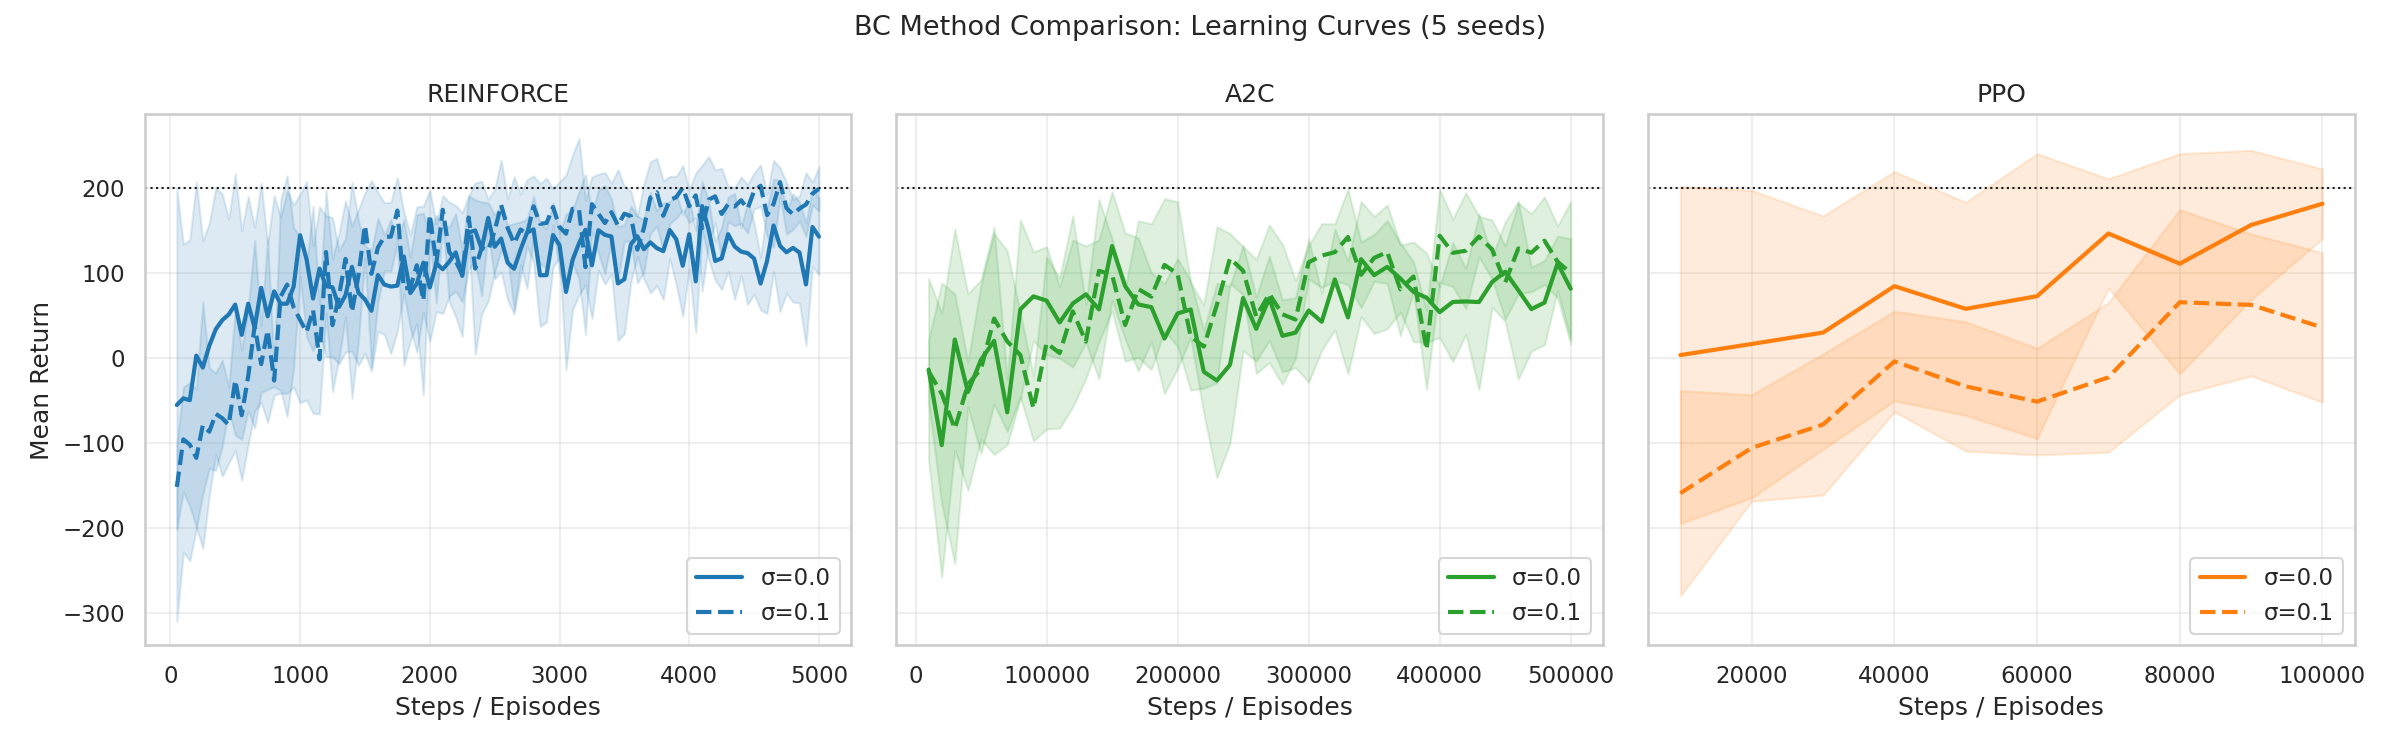

In [74]:
# Pre-generated learning curves
Image(filename=os.path.join(FIGURES_DIR, "bc_method_comparison_curves.png"), width=900)

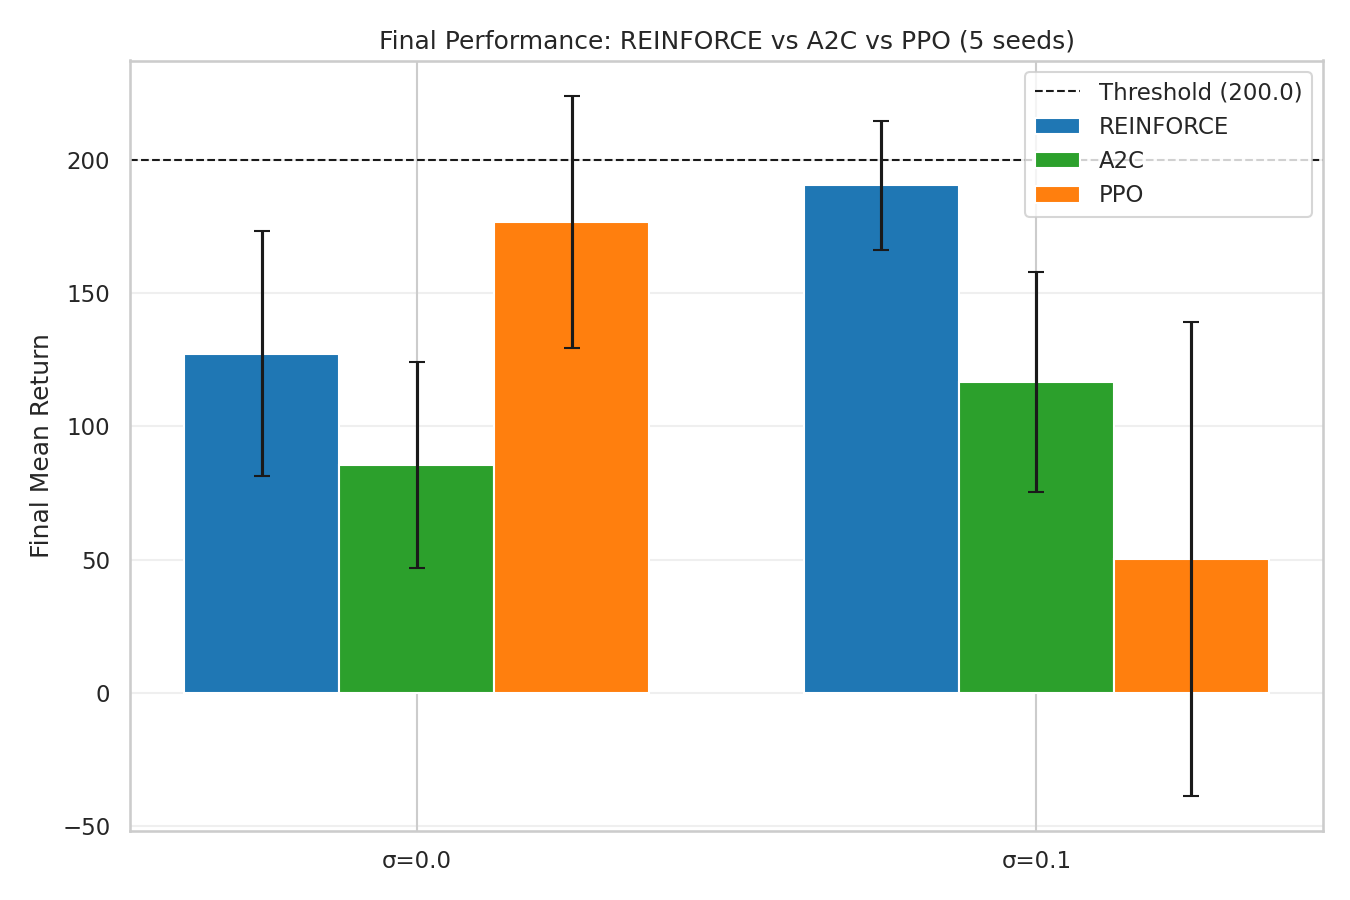

In [75]:
# Final comparison bar chart
Image(filename=os.path.join(FIGURES_DIR, "bc_method_comparison_final_comparison.png"), width=700)

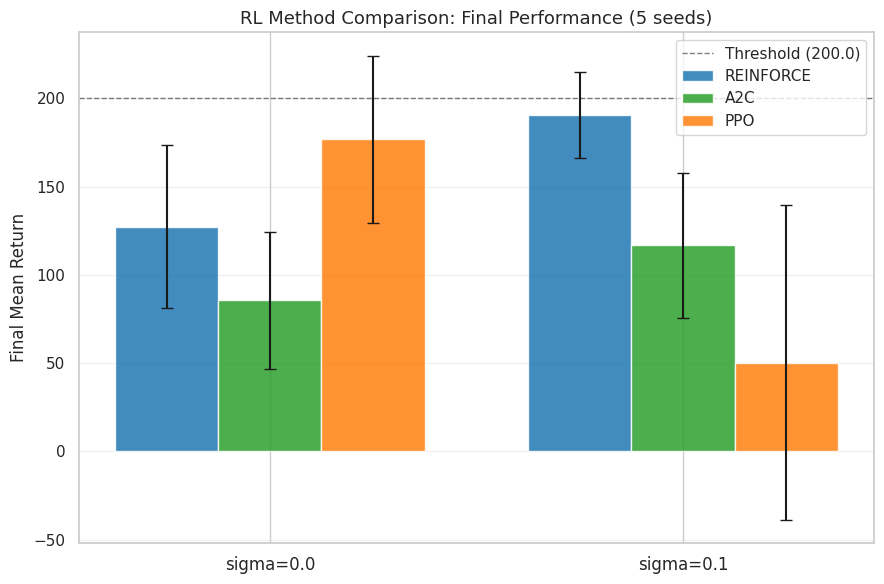

In [76]:
# Recreate grouped bar chart from loaded data
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(NOISE_STDS_MC))
width = 0.25
METHOD_COLORS = {"reinforce": "#1f77b4", "a2c": "#2ca02c", "ppo": "#ff7f0e"}

for i, method in enumerate(METHODS):
    means = [np.mean(method_results[f"sigma_{s}"][method]["final_mean"]) for s in NOISE_STDS_MC]
    stds = [np.std(method_results[f"sigma_{s}"][method]["final_mean"]) for s in NOISE_STDS_MC]
    ax.bar(x + (i - 1) * width, means, width, yerr=stds,
           label=method.upper(), color=METHOD_COLORS[method], capsize=4, alpha=0.85)

ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1, alpha=0.5, label=f"Threshold ({THRESHOLD})")
ax.set_xticks(x)
ax.set_xticklabels([f"sigma={s}" for s in NOISE_STDS_MC], fontsize=12)
ax.set_ylabel("Final Mean Return", fontsize=12)
ax.set_title("RL Method Comparison: Final Performance (5 seeds)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Analysis

**Without augmentation ($\sigma = 0.0$):**
- **PPO** achieves the highest final return (~177 mean), despite having the smallest training budget (100k steps vs 500k for A2C). This highlights PPO's sample efficiency.
- **REINFORCE** reaches ~127, limited by its high-variance episode-level updates over 5000 episodes.
- **A2C** achieves ~86, suggesting that the shared-trunk architecture and RMSprop optimizer may not suit this fine-tuning setting well.

**With augmentation ($\sigma = 0.1$):**
- **REINFORCE** significantly improves to ~191 mean, the best overall result — noise augmentation helps REINFORCE the most.
- **A2C** improves modestly to ~117.
- **PPO** degrades to ~50 mean, confirming the finding from Experiment 5 that PPO is sensitive to noise augmentation.

**Key takeaways:**
1. REINFORCE with noise augmentation achieves the best overall performance across all conditions.
2. PPO is the most sample-efficient method (best without augmentation) but fragile to distributional perturbation from observation noise.
3. A2C underperforms both alternatives, possibly due to the shared-trunk architecture or the RMSprop optimizer.
4. The choice of RL algorithm and augmentation strategy interact strongly — they should be tuned together, not independently.

---
<a id="9-experiment-7-action-noise-and-kl-divergence"></a>
## 9. Experiment 7: Action Noise and KL Divergence Regularization

This section investigates two complementary techniques for addressing covariate shift:

1. **Action noise at data collection** (data-level): Replace expert actions with random ones at rate $\epsilon$ during demonstration collection, forcing the expert to visit off-trajectory states.
2. **KL divergence regularization** (training-level): Add a penalty $\beta_{\text{KL}} \cdot D_{\text{KL}}(\pi_\theta \| \pi_{\text{BC}})$ to the REINFORCE objective, keeping the fine-tuned policy close to the BC initialization.

### 9.1 Action Noise Ablation

**Setup:** Epsilon-greedy action noise $\epsilon \in \{0.0, 0.05, 0.1, 0.2, 0.3\}$, 500 demo transitions, REINFORCE (2000 episodes), 4 seeds.

Unlike observation noise (which perturbs training inputs), action noise perturbs the *data collection process*: the expert still *records* its optimal action, but *executes* a random action with probability $\epsilon$. This creates demonstrations where the expert is shown recovering from suboptimal states.

In [77]:
action_noise = load_results("action_noise_results.npy")
ACTION_EPS = [0.0, 0.05, 0.1, 0.2, 0.3]

print("Action Noise Ablation Results (4 seeds):")
print("=" * 75)
print(f"{'eps':>6} | {'BC Score':>10} | {'BC Std':>8} | {'Cov Shift':>10} | {'REINFORCE Final':>16}")
print("-" * 75)
for eps in ACTION_EPS:
    key = f"eps_{eps}"
    r = action_noise[key]
    print(f"{eps:>6.2f} | {np.mean(r['bc_mean']):>10.1f} | {np.mean(r['bc_std']):>8.1f} | "
          f"{np.mean(r['shift']):>10.4f} | {np.mean(r['reinforce_final_mean']):>16.1f}")

Action Noise Ablation Results (4 seeds):
   eps |   BC Score |   BC Std |  Cov Shift |  REINFORCE Final
---------------------------------------------------------------------------
  0.00 |      108.6 |     63.5 |     0.4297 |            100.7
  0.05 |      224.2 |     59.2 |     0.1517 |            152.2
  0.10 |      197.8 |     70.2 |     0.2619 |            131.8
  0.20 |      150.9 |    115.5 |     0.7077 |            172.8
  0.30 |      239.0 |     27.2 |     0.7600 |            195.6


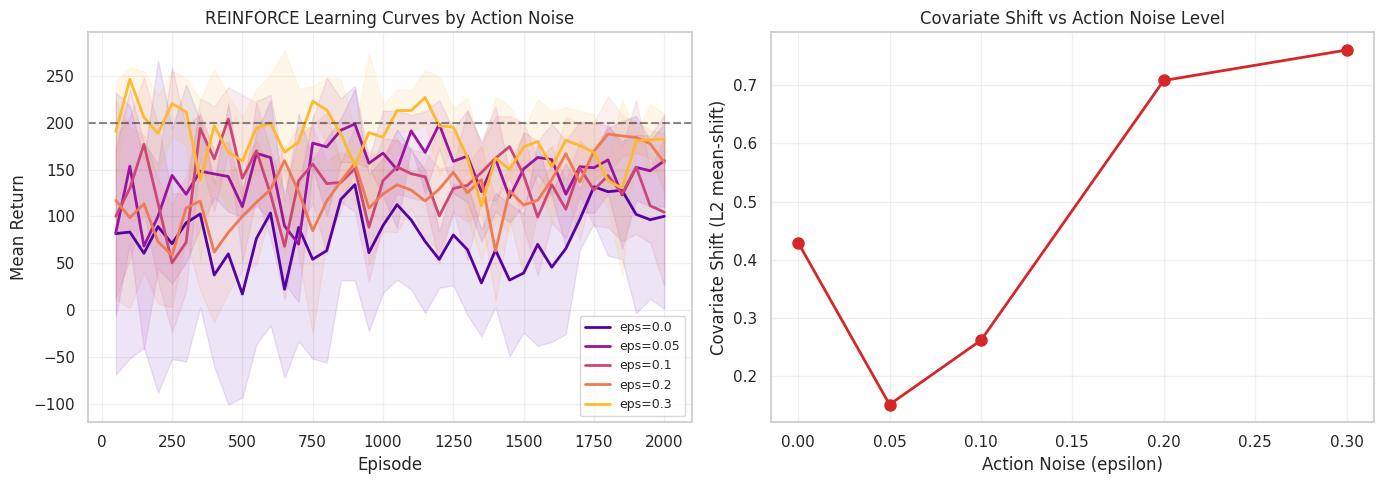

In [78]:
# Plot action noise learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_eps = plt.cm.plasma(np.linspace(0.15, 0.85, len(ACTION_EPS)))

# Left: learning curves
for i, eps in enumerate(ACTION_EPS):
    key = f"eps_{eps}"
    r = action_noise[key]
    curves = np.array(r["reinforce_curves"])
    x = np.array(r["reinforce_eval_at"])
    mean = curves.mean(axis=0)
    std = curves.std(axis=0)
    axes[0].plot(x, mean, label=f"eps={eps}", color=colors_eps[i], linewidth=2)
    axes[0].fill_between(x, mean - std, mean + std, alpha=0.1, color=colors_eps[i])

axes[0].axhline(THRESHOLD, color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Mean Return")
axes[0].set_title("REINFORCE Learning Curves by Action Noise")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: covariate shift vs epsilon
shifts = [np.mean(action_noise[f"eps_{e}"]["shift"]) for e in ACTION_EPS]
axes[1].plot(ACTION_EPS, shifts, 'o-', color='#d62728', linewidth=2, markersize=8)
axes[1].set_xlabel("Action Noise (epsilon)")
axes[1].set_ylabel("Covariate Shift (L2 mean-shift)")
axes[1].set_title("Covariate Shift vs Action Noise Level")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.2 KL Divergence Regularization

**Setup:** KL penalty coefficient $\beta_{\text{KL}} \in \{0.0, 0.01, 0.1, 0.5, 1.0\}$, 500 demo transitions, REINFORCE (1000 episodes), 3 seeds.

The modified REINFORCE objective becomes:

$$L_{\text{actor}} = -\mathbb{E}\left[A(s,a) \log \pi_\theta(a|s)\right] - \beta_{\text{ent}} H(\pi_\theta) + \beta_{\text{KL}} D_{\text{KL}}(\pi_\theta \| \pi_{\text{BC}})$$

The KL term penalizes the policy for diverging too far from its BC initialization, potentially preventing catastrophic forgetting while still allowing improvement.

Relevant implementation from `src/rl.py`:
```python
if cfg.kl_coef > 0.0:
    with torch.no_grad():
        ref_dist = self.ref_policy.get_distribution(obs_t)
    dist = self.policy.get_distribution(obs_t)
    kl_div = kl_divergence(dist, ref_dist).mean()
    kl_loss = cfg.kl_coef * kl_div
```

In [79]:
kl_results = load_results("kl_reinforce_results.npy")
KL_COEFS = [0.0, 0.01, 0.1, 0.5, 1.0]
kl_eval_at = np.array(kl_results["eval_at"])

print("KL Regularization Results (3 seeds):")
print("=" * 45)
print(f"{'beta_kl':>8} | {'Final Mean':>12} | {'Final Std':>10}")
print("-" * 45)
for kl in KL_COEFS:
    r = kl_results[kl]
    print(f"{kl:>8.2f} | {np.mean(r['rl_final_mean']):>12.1f} | {np.mean(r['rl_final_std']):>10.1f}")

KL Regularization Results (3 seeds):
 beta_kl |   Final Mean |  Final Std
---------------------------------------------
    0.00 |         60.2 |       47.9
    0.01 |         43.2 |       41.3
    0.10 |         95.6 |       12.3
    0.50 |         80.6 |       25.3
    1.00 |         54.7 |       26.7


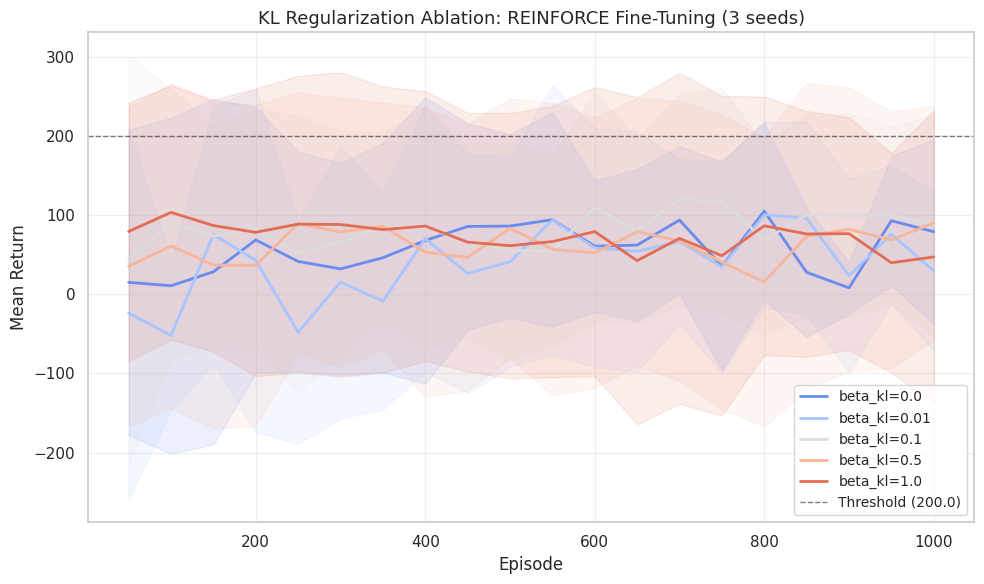

In [80]:
# Plot KL regularization learning curves
fig, ax = plt.subplots(figsize=(10, 6))
colors_kl = plt.cm.coolwarm(np.linspace(0.15, 0.85, len(KL_COEFS)))

for i, kl in enumerate(KL_COEFS):
    r = kl_results[kl]
    curves = np.array(r["rl_curves"])
    mean = curves.mean(axis=0)
    std = curves.std(axis=0)
    ax.plot(kl_eval_at[:len(mean)], mean, label=f"beta_kl={kl}", color=colors_kl[i], linewidth=2)
    ax.fill_between(kl_eval_at[:len(mean)], mean - std, mean + std, alpha=0.12, color=colors_kl[i])

ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1, alpha=0.5, label=f"Threshold ({THRESHOLD})")
ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Mean Return", fontsize=12)
ax.set_title("KL Regularization Ablation: REINFORCE Fine-Tuning (3 seeds)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 Combined: Action Noise + KL Ablation

**Setup:** A grid of $\epsilon \in \{0.0, 0.2, 0.3\}$ and $\beta_{\text{KL}} \in \{0.0, 0.1, 0.5\}$, REINFORCE (1000 episodes), 4 seeds.

This experiment tests whether action noise (data-level) and KL regularization (training-level) are complementary techniques for combating covariate shift.

In [81]:
combined = load_results("action_noise_kl_ablation.npy")
ACTION_EPS_C = [0.0, 0.2, 0.3]
KL_COEFS_C = [0.0, 0.1, 0.5]

print("Combined Action Noise + KL Ablation (Final Mean Return, 4 seeds):")
print("=" * 55)
corner = 'eps \\ kl'
header = f"{corner:>12}" + "".join(f"{'kl=' + str(k):>12}" for k in KL_COEFS_C)
print(header)
print("-" * 55)
for eps in ACTION_EPS_C:
    row = f"{'eps=' + str(eps):>12}"
    for kl in KL_COEFS_C:
        data = combined[eps][kl]
        final = np.mean(data["final"])
        row += f"{final:>12.1f}"
    print(row)

Combined Action Noise + KL Ablation (Final Mean Return, 4 seeds):
    eps \ kl      kl=0.0      kl=0.1      kl=0.5
-------------------------------------------------------
     eps=0.0       107.6       102.1       111.2
     eps=0.2       159.7       170.1       187.2
     eps=0.3       140.4       218.9       234.0


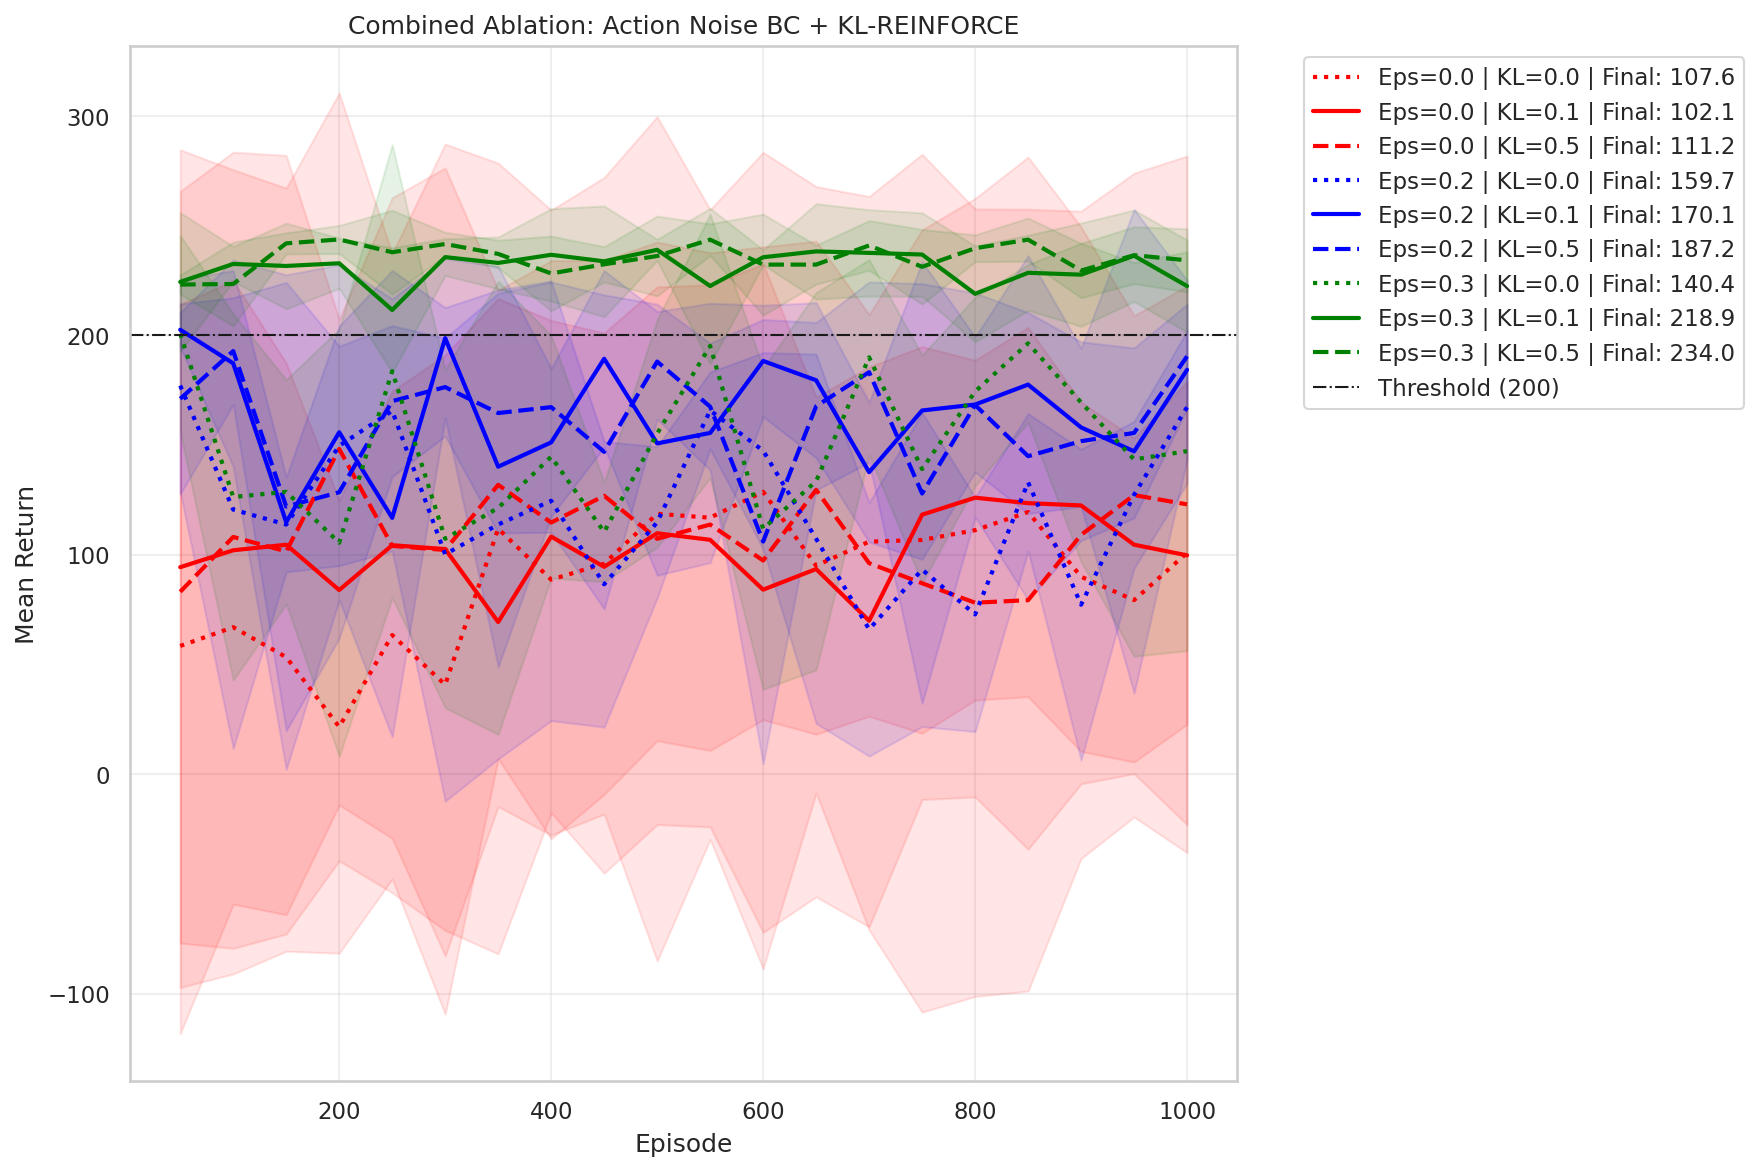

In [82]:
# Pre-generated combined ablation figures
Image(filename=os.path.join(FIGURES_DIR, "action_noise_kl_ablation_curves.png"), width=850)

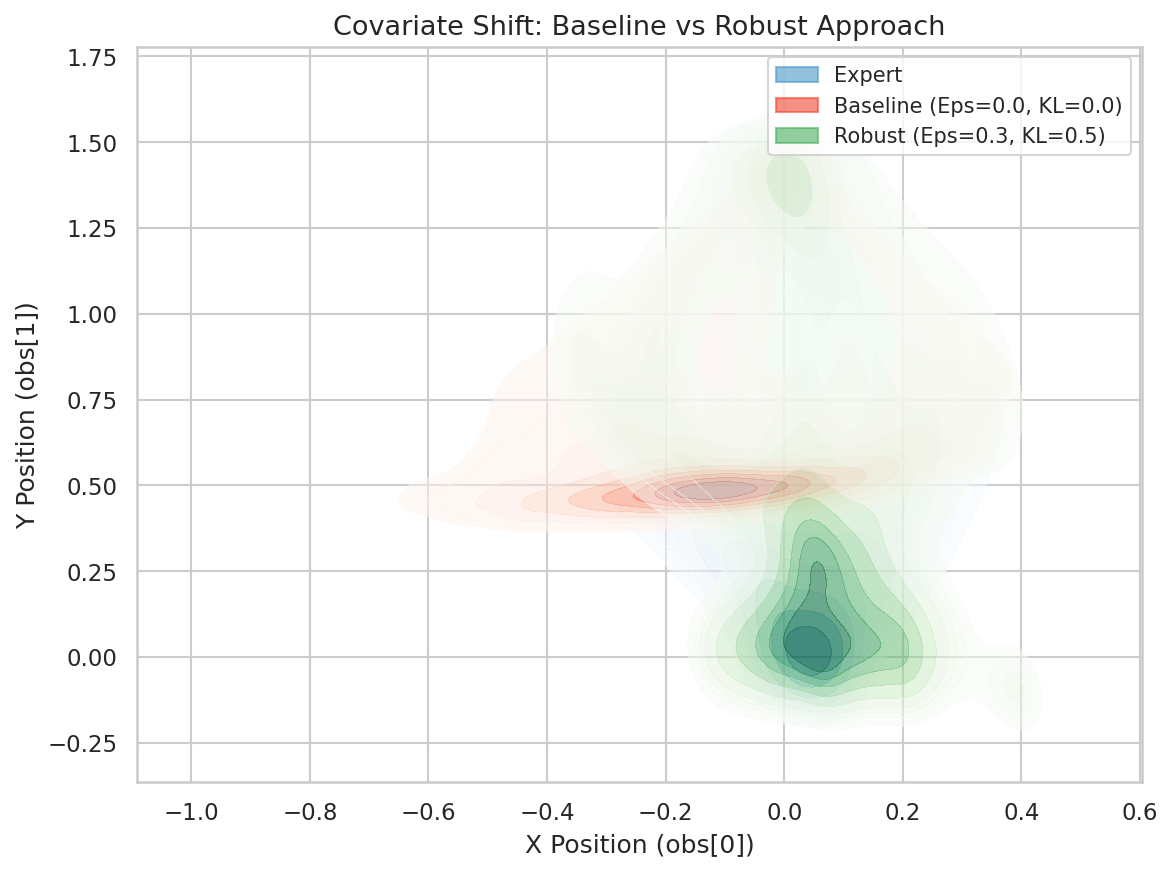

In [83]:
# Covariate shift figure
Image(filename=os.path.join(FIGURES_DIR, "action_noise_kl_covariate_shift.png"), width=700)

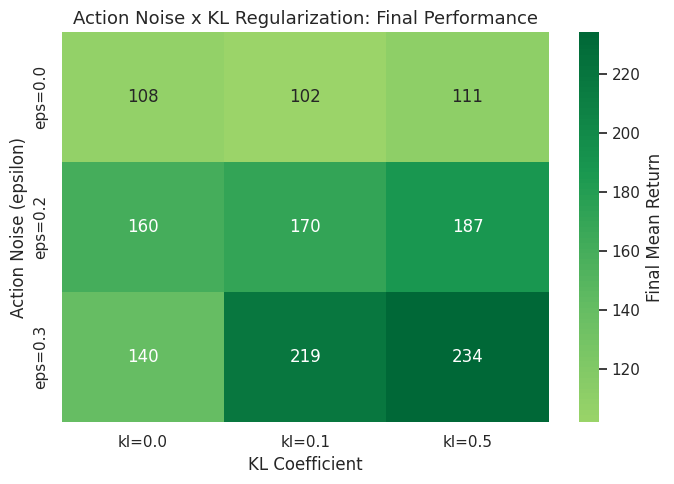

In [84]:
# Heatmap of final performance across the grid
fig, ax = plt.subplots(figsize=(7, 5))

grid = np.zeros((len(ACTION_EPS_C), len(KL_COEFS_C)))
for i, eps in enumerate(ACTION_EPS_C):
    for j, kl in enumerate(KL_COEFS_C):
        grid[i, j] = np.mean(combined[eps][kl]["final"])

sns.heatmap(grid, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            xticklabels=[f"kl={k}" for k in KL_COEFS_C],
            yticklabels=[f"eps={e}" for e in ACTION_EPS_C],
            ax=ax, cbar_kws={"label": "Final Mean Return"})
ax.set_title("Action Noise x KL Regularization: Final Performance", fontsize=13)
ax.set_xlabel("KL Coefficient")
ax.set_ylabel("Action Noise (epsilon)")
plt.tight_layout()
plt.show()

### Analysis

**Action noise alone (from Section 9.1):**
- Without action noise ($\epsilon = 0$), BC quality is unstable across seeds (high variance), and REINFORCE final performance averages ~101.
- Moderate action noise ($\epsilon = 0.05$–$0.2$) generally helps by reducing covariate shift and providing more diverse demonstrations, improving downstream RL.
- At $\epsilon = 0.3$, BC achieves high mean scores and REINFORCE reaches ~196 on average — the best single action-noise condition.

**KL regularization alone (from Section 9.2):**
- The KL results (3 seeds, 1000 episodes) show high variance. Looking at the mean across seeds: $\beta = 0.1$ achieves the best average final return (~96), outperforming no regularization ($\beta = 0$, ~60). However, higher KL coefficients ($\beta = 0.5$, $\beta = 1.0$) degrade performance, suggesting that too much constraint prevents the policy from improving.
- With only 3 seeds and high per-seed variance (e.g., $\beta = 0$: [-47, 126, 101]), these results should be interpreted cautiously.

**Combined (from Section 9.3):**
- The heatmap above reveals that action noise and KL regularization are **complementary**:
  - Without action noise ($\epsilon = 0$), KL regularization has mixed effects (all results near 100–110).
  - With moderate action noise ($\epsilon = 0.2$), KL regularization provides a consistent boost: from ~160 (KL=0) to ~187 (KL=0.5).
  - The best overall result is at $\epsilon = 0.3$, $\beta_{\text{KL}} = 0.5$ (mean ~234), where action noise provides diverse data and KL regularization stabilizes training.
- At $\epsilon = 0.3$ without KL, performance is lower (~140), but adding KL=0.1 boosts it to ~219 and KL=0.5 to ~234.

**Key takeaway:** Action noise and KL regularization are complementary: action noise provides the diverse state coverage needed for good RL, while KL regularization prevents the policy from diverging too far from its initialization. The combination achieves the best results in this experiment.

---
<a id="10-summary-and-conclusions"></a>
## 10. Summary and Conclusions

In [85]:
# Grand summary table — all values computed dynamically from loaded data
summary_data = {
    "Experiment": [
        "1. Main Comparison",
        "2. Demo Size Ablation",
        "3. Expert Quality",
        "4. BC + PPO",
        "4. BC + PPO + Annealing",
        "5. Obs Noise Aug (V2)",
        "6. Method Comparison",
        "7a. Action Noise",
        "7b. KL Regularization",
        "7c. Action Noise + KL",
    ],
    "Key Finding": [
        "BC+REINFORCE starts strong; RL scratch starts at ~-498",
        f"RL helps at N=100 (uplift +{demo_size_results[100]['eval_mean'][-1] - demo_size_results[100]['bc_only_mean']:.0f}); hurts at N>=500",
        "Weak expert (50k) doesn't recover; 500k best",
        f"BC+PPO: {ppo_results['ppo']['mean']:.0f} vs BC: {ppo_results['bc']['mean']:.0f} (marginal)",
        f"Entropy annealing: {annealing_results['ppo_annealing']['mean']:.0f} (modest improvement)",
        f"sigma=0.05 best for REINFORCE ({np.mean(aug_v2['sigma_0.05']['reinforce_final_mean']):.0f}); PPO degrades with noise",
        f"REINFORCE+aug best overall ({np.mean(method_results['sigma_0.1']['reinforce']['final_mean']):.0f}); PPO fragile to noise",
        f"eps=0.3 best ({np.mean(action_noise['eps_0.3']['reinforce_final_mean']):.0f}); reduces cov. shift",
        f"Moderate KL (0.1) helps ({np.mean(kl_results[0.1]['rl_final_mean']):.0f}); high KL hurts",
        f"Best: eps=0.3+KL=0.5 -> {np.mean(combined[0.3][0.5]['final']):.0f} (complementary)",
    ],
    "Seeds": [5, 5, 5, 1, 1, 5, 5, 4, 3, 4],
}

df_summary = pd.DataFrame(summary_data)
display(df_summary.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

Experiment,Key Finding,Seeds
1. Main Comparison,BC+REINFORCE starts strong; RL scratch starts at ~-498,5
2. Demo Size Ablation,RL helps at N=100 (uplift +515); hurts at N>=500,5
3. Expert Quality,Weak expert (50k) doesn't recover; 500k best,5
4. BC + PPO,BC+PPO: 235 vs BC: 231 (marginal),1
4. BC + PPO + Annealing,Entropy annealing: 245 (modest improvement),1
5. Obs Noise Aug (V2),sigma=0.05 best for REINFORCE (191); PPO degrades with noise,5
6. Method Comparison,REINFORCE+aug best overall (191); PPO fragile to noise,5
7a. Action Noise,eps=0.3 best (196); reduces cov. shift,4
7b. KL Regularization,Moderate KL (0.1) helps (96); high KL hurts,3
7c. Action Noise + KL,Best: eps=0.3+KL=0.5 -> 234 (complementary),4


### Key Findings

1. **BC + RL fine-tuning can be powerful, but is not universally better than BC alone.** In the main comparison (Experiment 1), BC+REINFORCE maintains strong performance from the start, far outpacing RL-from-scratch. However, the demo size ablation (Experiment 2) reveals that when BC alone is already strong (N≥500), REINFORCE fine-tuning can actually *degrade* performance — policy gradient methods can destabilize a good initialization.

2. **Covariate shift is the central theme.** Multiple complementary strategies address it:
   - *RL fine-tuning* optimizes under the agent's own distribution.
   - *Observation noise augmentation* broadens the BC training distribution.
   - *Action noise in data collection* creates demonstrations from off-trajectory states.
   - *KL regularization* prevents catastrophic divergence during RL (but only at moderate levels).

3. **Algorithm choice matters and interacts with augmentation.** REINFORCE with augmented BC achieves the best overall performance in the method comparison. PPO is the most sample-efficient without augmentation but is fragile to observation noise. A2C underperforms both alternatives.

4. **Augmentation and regularization are complementary.** The combined action noise + KL experiment shows their best results together (eps=0.3 + KL=0.5 → ~234 mean return), where noise provides diverse training signal and KL prevents catastrophic forgetting.

5. **High variance is a recurring challenge.** Many experiments show large per-seed variance, especially with small seed counts (3-4 seeds). This makes it difficult to draw strong quantitative conclusions from individual experiments; the qualitative trends across experiments are more reliable.

### Limitations

- **Single environment**: All experiments use LunarLander-v3. Findings may not transfer to continuous action spaces or high-dimensional observations.
- **Covariate shift metric**: We use L2 mean-shift as a proxy for distributional divergence. More principled metrics (MMD, Wasserstein) could be more informative.
- **No DAgger comparison**: DAgger (Ross et al., 2011) is the canonical solution to covariate shift in imitation learning. We compare RL fine-tuning as an alternative but do not directly compare to DAgger.
- **Limited hyperparameter tuning**: Each RL algorithm uses a single set of hyperparameters. Performance could potentially be improved with algorithm-specific tuning.
- **Seed counts**: Some experiments use only 3-4 seeds, which is not sufficient for statistically significant conclusions given the observed variance.

### Future Work

- Extend to continuous control (e.g., LunarLanderContinuous, BipedalWalker).
- Implement DAgger for direct comparison.
- Explore non-linear entropy annealing schedules (cosine, exponential).
- Use proper distributional metrics (Maximum Mean Discrepancy) for covariate shift measurement.
- Increase seed counts to 10+ for experiments with high variance.
- Investigate why REINFORCE degrades BC performance at high demo counts (Experiment 2) — potential fixes include learning rate scheduling, early stopping, or shorter fine-tuning.

---
<a id="11-references"></a>
## 11. References

1. Ross, S., Gordon, G., & Bagnell, D. (2011). *A Reduction of Imitation Learning and Structured Prediction to No-Regret Online Learning.* AISTATS.
2. Ross, S., & Bagnell, D. (2010). *Efficient Reductions for Imitation Learning.* AISTATS.
3. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal Policy Optimization Algorithms.* arXiv:1707.06347.
4. Williams, R. J. (1992). *Simple statistical gradient-following algorithms for connectionist reinforcement learning.* Machine Learning, 8(3), 229-256.
5. Mnih, V., et al. (2016). *Asynchronous Methods for Deep Reinforcement Learning.* ICML. (A2C/A3C)
6. Raffin, A., Hill, A., Gleave, A., et al. (2021). *Stable-Baselines3: Reliable Reinforcement Learning Implementations.* JMLR.

---
<a id="12-appendix-hyperparameters"></a>
## 12. Appendix: Hyperparameters

### Expert Training (SB3 PPO)
| Parameter | Value |
|-----------|-------|
| Total timesteps | 500,000 |
| Parallel environments | 4 |
| Learning rate | 3e-4 |
| Batch size | 64 |
| n_steps | 1,024 |
| Gamma | 0.999 |
| GAE lambda | 0.98 |
| Entropy coefficient | 0.01 |
| Checkpoint frequency | Every 50k steps |

### Behavioral Cloning
| Parameter | Value |
|-----------|-------|
| Optimizer | Adam |
| Learning rate | 1e-3 |
| Batch size | 256 |
| Max epochs | 50 |
| Early stopping patience | 10 |
| Validation split | 10% |
| Gradient clipping | max_norm=1.0 |
| Loss function | Cross-entropy |

### REINFORCE
| Parameter | Value |
|-----------|-------|
| Episodes | 2,000–5,000 (varies by experiment) |
| Discount (gamma) | 0.99 |
| Actor learning rate | 3e-4 |
| Critic learning rate | 1e-3 |
| Entropy coefficient | 0.01 |
| Gradient clipping | max_norm=1.0 |
| Evaluation frequency | Every 50 episodes |
| Evaluation episodes | 20 |

### A2C
| Parameter | Value |
|-----------|-------|
| Total steps | 500,000 |
| n_steps (TD) | 5 |
| Discount (gamma) | 0.99 |
| Optimizer | RMSprop |
| Learning rate | 7e-4 |
| Entropy coefficient | 0.01 |
| Value coefficient | 0.5 |
| Evaluation frequency | Every 10k steps |

### PPO Fine-Tuning
| Parameter | Value |
|-----------|-------|
| Total steps | 100k (method comparison) / 500k (standalone) |
| net_arch | [256, 256] (must match BC) |
| Entropy coefficient | 0.01 (or annealed 0.02→0.001) |
| Device | CPU (SB3 recommendation for MlpPolicy) |

### Network Architecture
| Component | Architecture |
|-----------|-------------|
| PolicyNetwork | MLP: 8 → 256 (Tanh) → 256 (Tanh) → 4 |
| ActorCriticNetwork trunk | 8 → 256 (Tanh) → 256 (Tanh) |
| Actor head | 256 → 256 (Tanh) → 4 |
| Critic head | 256 → 256 (Tanh) → 1 |
| ValueNetwork (REINFORCE) | Same dims as PolicyNetwork, output 1 |

### Appendix: Saved Artifacts

All experiment results are stored in the repository for reproducibility:

| File | Contents |
|------|----------|
| `results/main_comparison.npy` | RL scratch / BC only / BC+REINFORCE comparison |
| `results/demo_size_ablation.npy` | Demo size N ∈ {100, 500, 1000, 2000} |
| `results/expert_quality_ablation.npy` | Expert at 50k / 200k / 500k steps |
| `results/bc_ppo_results.npy` | BC → PPO fine-tuning |
| `results/bc_ppo_annealing.npy` | BC → PPO with entropy annealing |
| `results/bc_aug_results.npy` | Observation noise V1 (σ=0 vs σ=0.1) |
| `results/bc_aug_v2_results.npy` | Observation noise V2 (σ sweep, REINFORCE+PPO) |
| `results/bc_method_comparison.npy` | REINFORCE vs A2C vs PPO × {σ=0, σ=0.1} |
| `results/action_noise_results.npy` | Action noise ε ∈ {0, 0.05, 0.1, 0.2, 0.3} |
| `results/kl_reinforce_results.npy` | KL penalty β ∈ {0, 0.01, 0.1, 0.5, 1.0} |
| `results/action_noise_kl_ablation.npy` | Combined ε × β grid |
| `checkpoints/expert/best/best_model.zip` | Best PPO expert |
| `checkpoints/bc/best_bc.pt` | BC PolicyNetwork weights |
| `checkpoints/reinforce/reinforce_final.pt` | REINFORCE policy + value network |
| `data/demonstrations_200ep.npz` | 200-episode expert demonstration dataset |